# Classwork 7: Data Visualization
## Getting Ready

<User username:adrawal_asu>
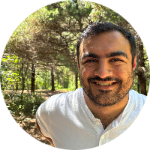

In [3]:
# import the arcgis package  # ArcGIS Python API: access ArcGIS Online/Enterprise programmatically
         # provides GIS, content, features, mapping, and analysis modules; pip install arcgis if missing
import arcgis
# set up ArcGIS Online credentials  # using the 'home' profile uses locally stored credentials (ArcGIS Pro or .arcgisprofile)
        # creates a GIS object connected to your default portal; alternatively supply URL and credentials
gis = arcgis.GIS("home")
# display my user information  # shows the authenticated user object, useful to confirm login and privileges
        # returns a User object with username, role, orgId, and other metadata; can be printed or inspected
gis.users.me

<Item title:"Esri Updated Demographics USA Variables 2024" type:Feature Layer Collection owner:esri_premium>
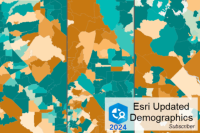

In [4]:
# fetch the 2024 census housing item by its ArcGIS Online item id  # item id is unique to the hosted feature service or map
'b0b3b31e531e406185f2de4fff596060'  # returns Item or None if not found
item_2024_census_housing = gis.content.get('b0b3b31e531e406185f2de4fff596060')
# display the item summary: .title, .type, .url, .properties
item_2024_census_housing

## Preprocessing Data

In [6]:
# iterate the layers inside the item (if the item is a Feature Service or Map Service it will have layers)
for i, lyr in enumerate(item_2024_census_housing.layers):
    # enumerate gives index + layer object
    print(f"Layer {i}: {lyr.properties.name}")  # print index to choose the correct layer by position or name

Layer 0: USA
Layer 1: Congressional_District
Layer 2: State
Layer 3: County
Layer 4: Tract


In [ ]:
# pick the counties layer by index 3 — change index if layers differ in your item
lyr_counties = item_2024_census_housing.layers[3]
    # A FeatureLayer object with query(), properties, and renderer info
df_arizona = lyr_counties.query(
    where="STATE_NAME='Arizona'",
    as_df=True,
    return_geometry=False)

In [15]:
# inspect the attribute fields on the counties layer  # useful to know column names and types
lyr_counties.properties.fields
    # list of dicts: [{'name': 'FIELDNAME', 'type': 'esriFieldTypeString', 'alias': 'Field Alias'}, ...]

[{
   "name": "OBJECTID",
   "type": "esriFieldTypeOID",
   "alias": "OBJECTID",
   "sqlType": "sqlTypeOther",
   "nullable": false,
   "editable": false,
   "domain": null,
   "defaultValue": null,
   "required": true
 },
 {
   "name": "ID",
   "type": "esriFieldTypeString",
   "alias": "Geographic Area Code (no decimal separator, if applicable)",
   "sqlType": "sqlTypeOther",
   "length": 5,
   "nullable": true,
   "editable": true,
   "domain": null,
   "defaultValue": null,
   "description": "{\"value\":\"Geographic Identifier, or GEOID is the numeric code used to uniquely identify all administrative/legal and statistical geographic areas for which the Census Bureau tabulates data.\",\"fieldValueType\":\"uniqueIdentifier\"}"
 },
 {
   "name": "NAME",
   "type": "esriFieldTypeString",
   "alias": "Geographic Area Name or Code (with decimal separator, if applicable)",
   "sqlType": "sqlTypeOther",
   "length": 46,
   "nullable": true,
   "editable": true,
   "domain": null,
   "defau

In [16]:
# query the counties layer to get only Arizona rows and return as a pandas DataFrame
    # FeatureLayer.query returns FeatureSet; as_df=True converts attributes to pandas DataFrame
    # SQL where clause; adjust if your state field has a different name or formatting
    # ask for a DataFrame which is convenient for plotting and manipulation
    # geometry often large; set True only if spatial operations or mapping are needed

df_arizona = lyr_counties.query(
    where="STATE_NAME='Arizona'",
    as_df=True,
    return_geometry=False)

In [17]:
# build a mapping of raw field names to their human-friendly aliases (if available)
    # dictionary to map column name -> alias
    # iterate each field definition from the service
        # use alias if provided, else fallback to the raw name

field_aliases = {}
for f in lyr_counties.properties.fields:
    field_aliases[f['name']] = f.get('alias', f['name'])

# rename the DataFrame columns to use the field aliases for easier reading in charts and outputs
    # this creates nicer column headers like '2024 Total Housing Units (Esri)'
df_arizona = df_arizona.rename(columns=field_aliases)

In [18]:
# show the DataFrame columns after renaming so you can pick the one to plot
    # returns an Index object listing all column names (aliases applied)
df_arizona.columns

Index(['OBJECTID',
       'Geographic Area Code (no decimal separator, if applicable)',
       'Geographic Area Name or Code (with decimal separator, if applicable)',
       'State Name', 'State Abbreviation', 'Total Area in Square Miles',
       '2024 Total Population (Esri)', '2024 Household Population (Esri)',
       '2024 Group Quarters Population (Esri)',
       '2024 Population Density (Pop per Square Mile) (Esri)',
       ...
       '2024 Percent Hispanic Population (Esri)',
       '2024 Percent White Non-Hispanic Population (Esri)',
       '2024 Percent Black/African American Non-Hispanic Population (Esri)',
       '2024 Percent American Indian/Alaska Native Non-Hispanic Population (Esri)',
       '2024 Percent Asian Non-Hispanic Population (Esri)',
       '2024 Percent Pacific Islander Non-Hispanic Population (Esri)',
       '2024 Percent Other Race Non-Hispanic Population (Esri)',
       '2024 Percent Multiple Races Non-Hispanic Population (Esri)',
       '2024 Percent of Pop

## Charting the Gathered Data

<Axes: >

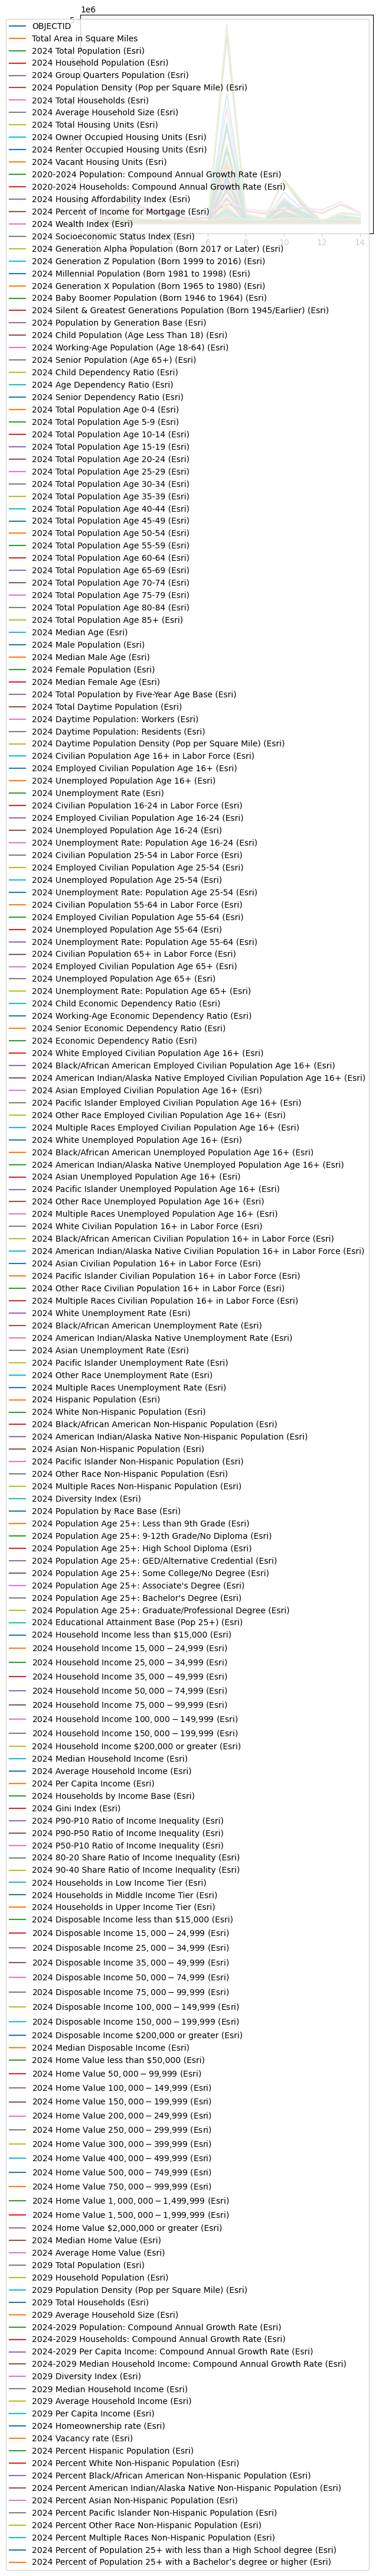

In [19]:
# a quick default plot of the DataFrame
    # pandas will attempt to plot numeric columns using it's best judgement
df_arizona.plot()

<Axes: xlabel='Geographic Area Name or Code (with decimal separator, if applicable)'>

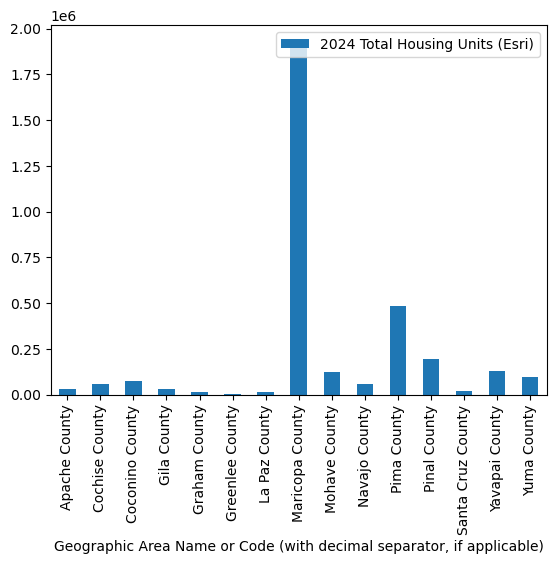

In [20]:
# explicit bar chart using a long alias column name for the x labels and the 2024 units for y
# pandas plotting wrapper around matplotlib
    # bar chart
    # categorical x-axis; ensure this column exists
    # numeric y-axis based on the field alias from the service
# may be slow if many rows; consider filtering or sampling

df_arizona.plot(
    kind='bar',
    x='Geographic Area Name or Code (with decimal separator, if applicable)',
    y='2024 Total Housing Units (Esri)'
)

In [27]:
# sort DataFrame by the housing units column so largest counties appear first
    # inplace reassignment for clarity
    # column used to sort
    # largest values first
df_arizona = df_arizona.sort_values(
    '2024 Total Housing Units (Esri)',
    ascending=False,
)

#Return the top 5 to review them
df_arizona[['Geographic Area Name or Code (with decimal separator, if applicable)', '2024 Total Housing Units (Esri)']].head()

,"Geographic Area Name or Code (with decimal separator, if applicable)",2024 Total Housing Units (Esri)
7,Maricopa County,1923989
10,Pima County,486176
11,Pinal County,194232
13,Yavapai County,128131
8,Mohave County,123744


<Axes: title={'center': '2024 Estimated Housing Units by County in Arizona'}, xlabel='County', ylabel='2024 Total Housing Units'>

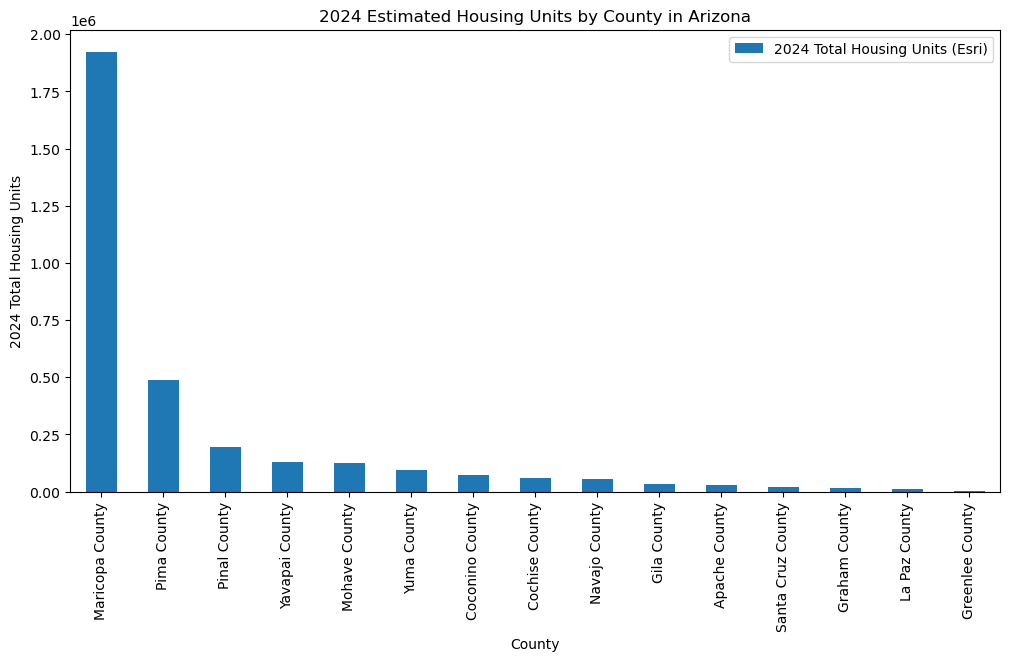

In [28]:
# improved pandas bar plot with labels, sizing and title
# use pandas/matplotlib to create a chart
    # bar chart for categorical comparison
    # x labels (county names)
    # numeric axis with housing units
    # width x height in inches
    # x-axis label
    # y-axis label
    # chart title
df_arizona.plot(
    kind='bar',
    x='Geographic Area Name or Code (with decimal separator, if applicable)',
    y='2024 Total Housing Units (Esri)',
    figsize=(12,6),
    xlabel='County',
    ylabel='2024 Total Housing Units',
    title='2024 Estimated Housing Units by County in Arizona'
)


## Repeating the process through multiple states

In [29]:
# get the unique state names available in the layer
# query only the STATE_NAME field

states_to_map = lyr_counties.query(
    out_fields=['STATE_NAME'],
    return_geometry=False,
    as_df=True
).STATE_NAME.unique()
# returns a numpy array of unique values
# print or inspect this list to see available states

states_to_map

<StringArray>
[          'California',             'Colorado', 'District of Columbia',
              'Florida',              'Georgia',               'Hawaii',
             'Illinois',              'Indiana',               'Kansas',
             'Kentucky',            'Louisiana',            'Minnesota',
          'Mississippi',             'Missouri',             'Nebraska',
               'Nevada',           'New Jersey',           'New Mexico',
             'New York',       'North Carolina',         'Pennsylvania',
         'Rhode Island',            'Tennessee',                'Texas',
             'Virginia',        'West Virginia',            'Wisconsin',
              'Alabama',             'Arkansas',                 'Iowa',
             'Maryland',        'Massachusetts',             'Michigan',
                 'Ohio',             'Oklahoma',       'South Carolina',
         'South Dakota',              'Vermont',          'Connecticut',
                'Idaho',        'New 

c:\Users\arjav\AppData\Local\ESRI\conda\envs\gis222venv\Lib\site-packages\pandas\plotting\_matplotlib\core.py:580: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = self.plt.figure(figsize=self.figsize)


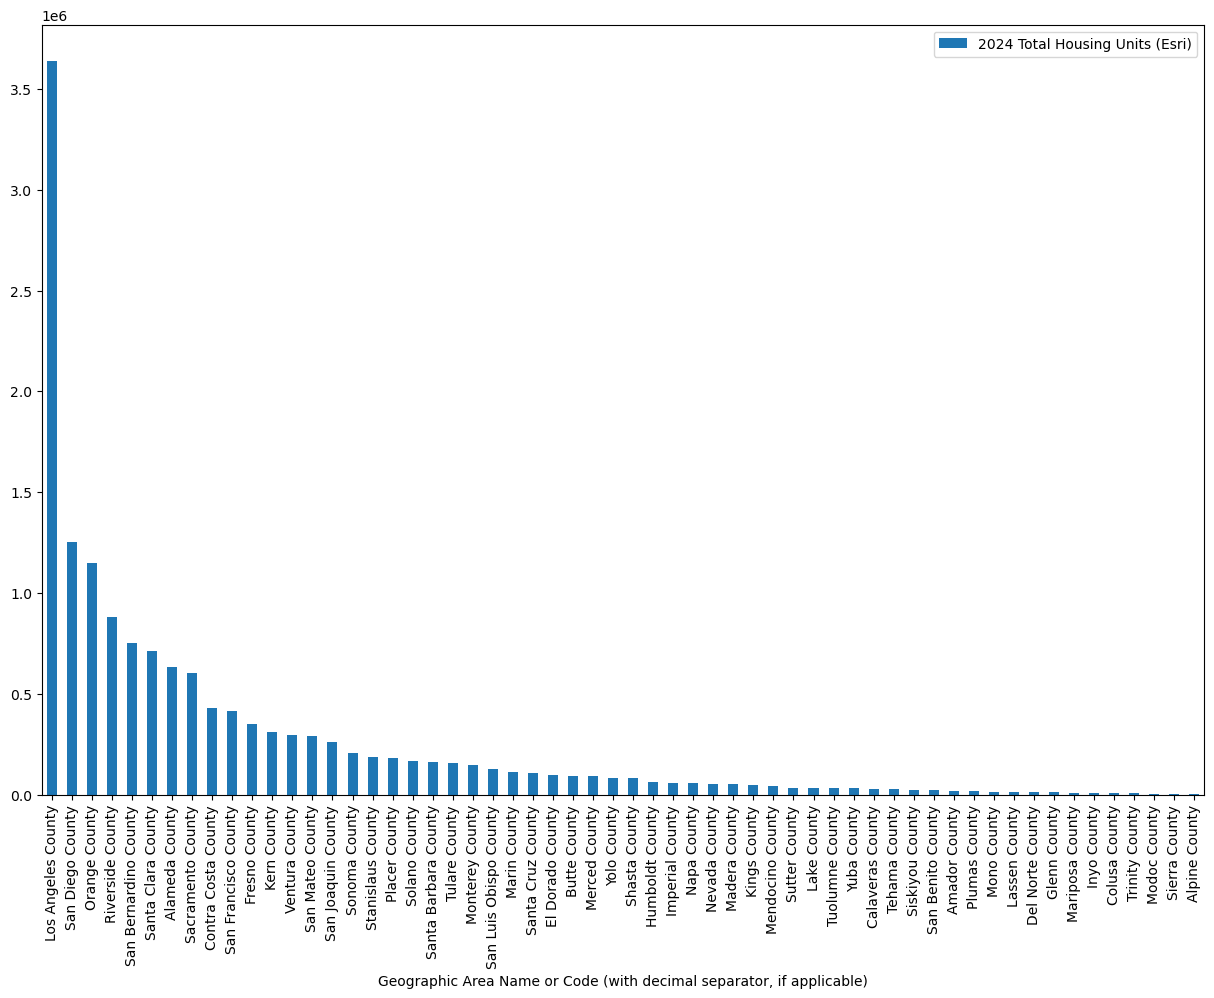

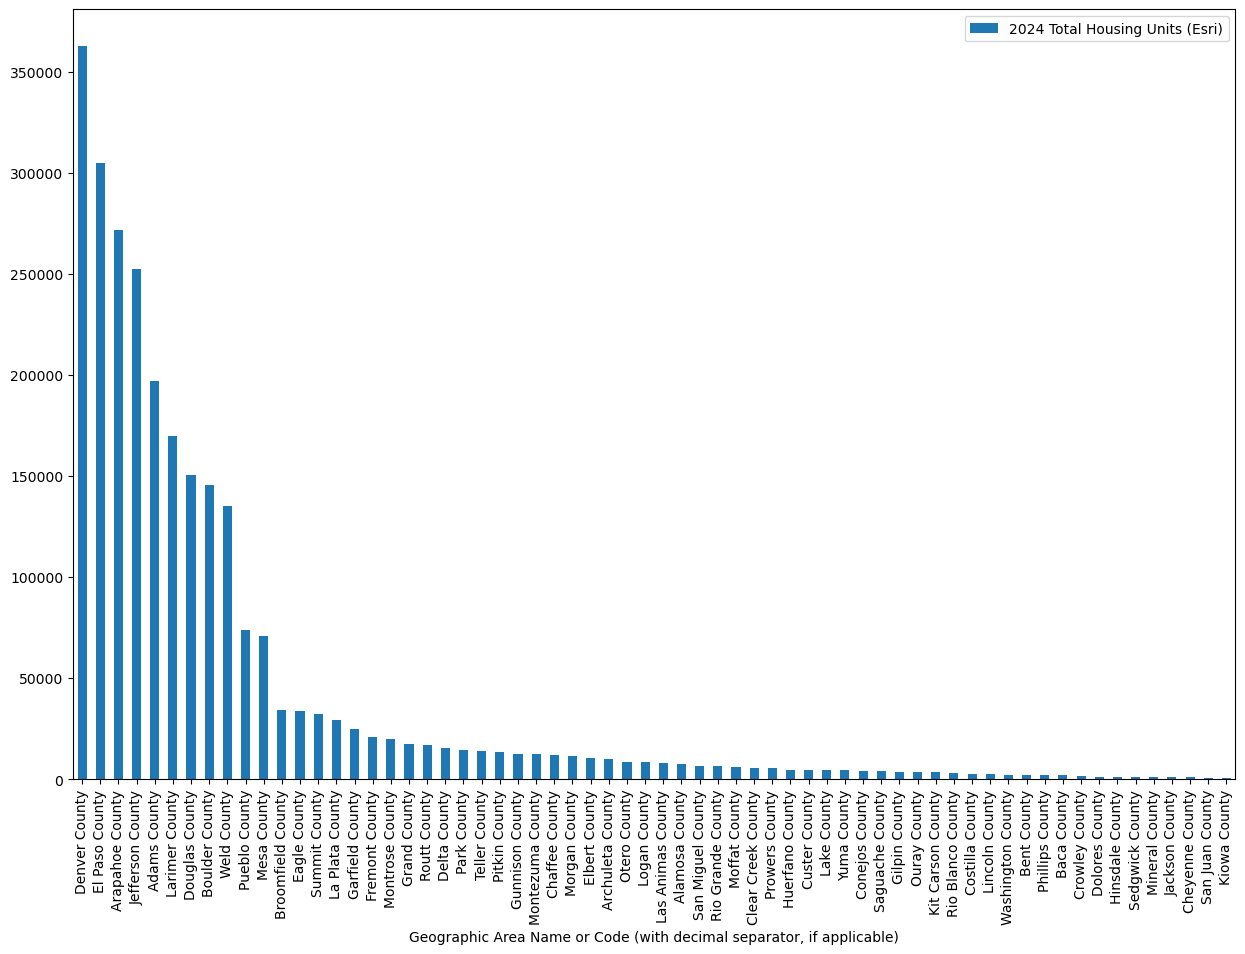

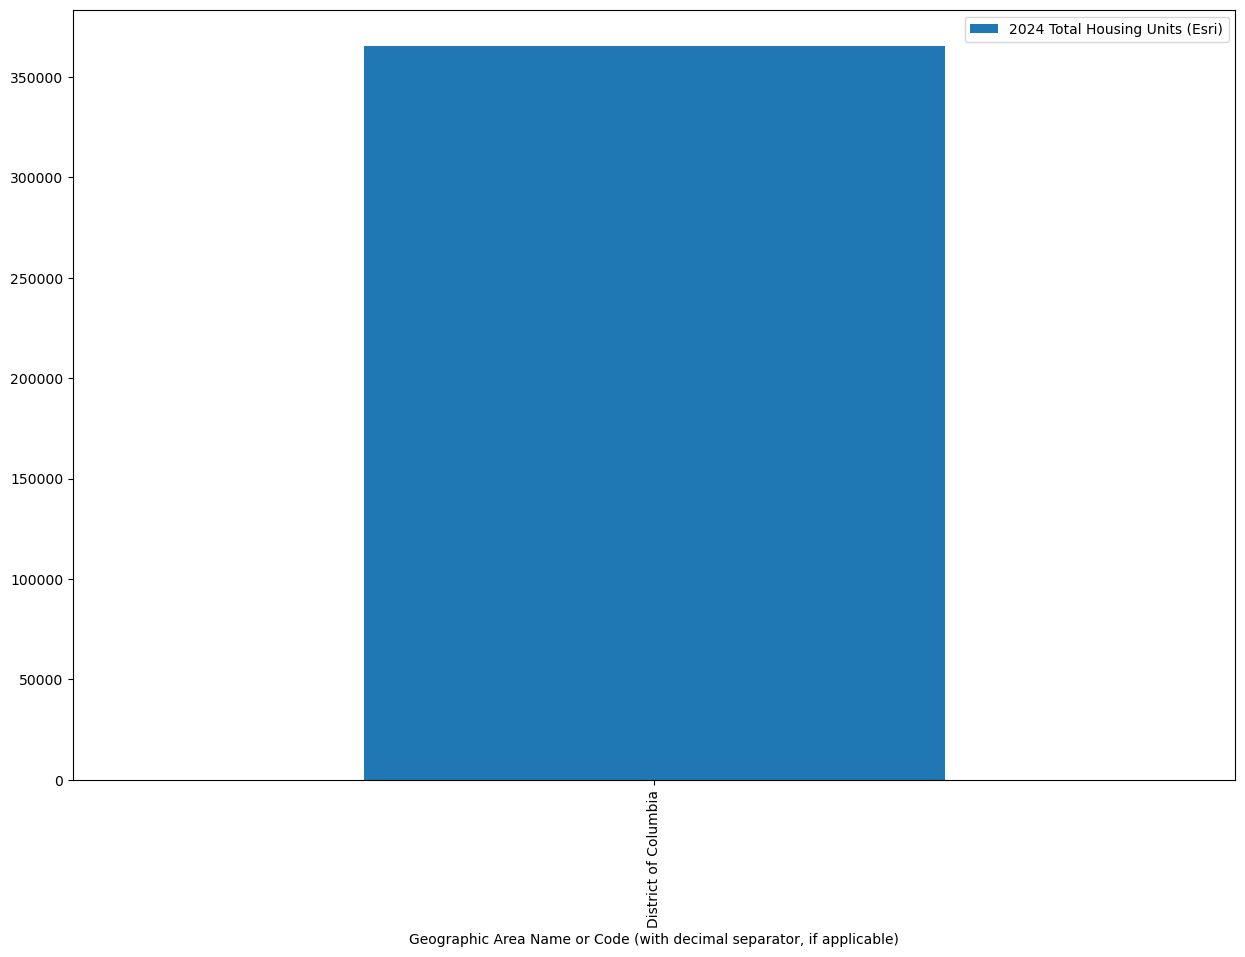

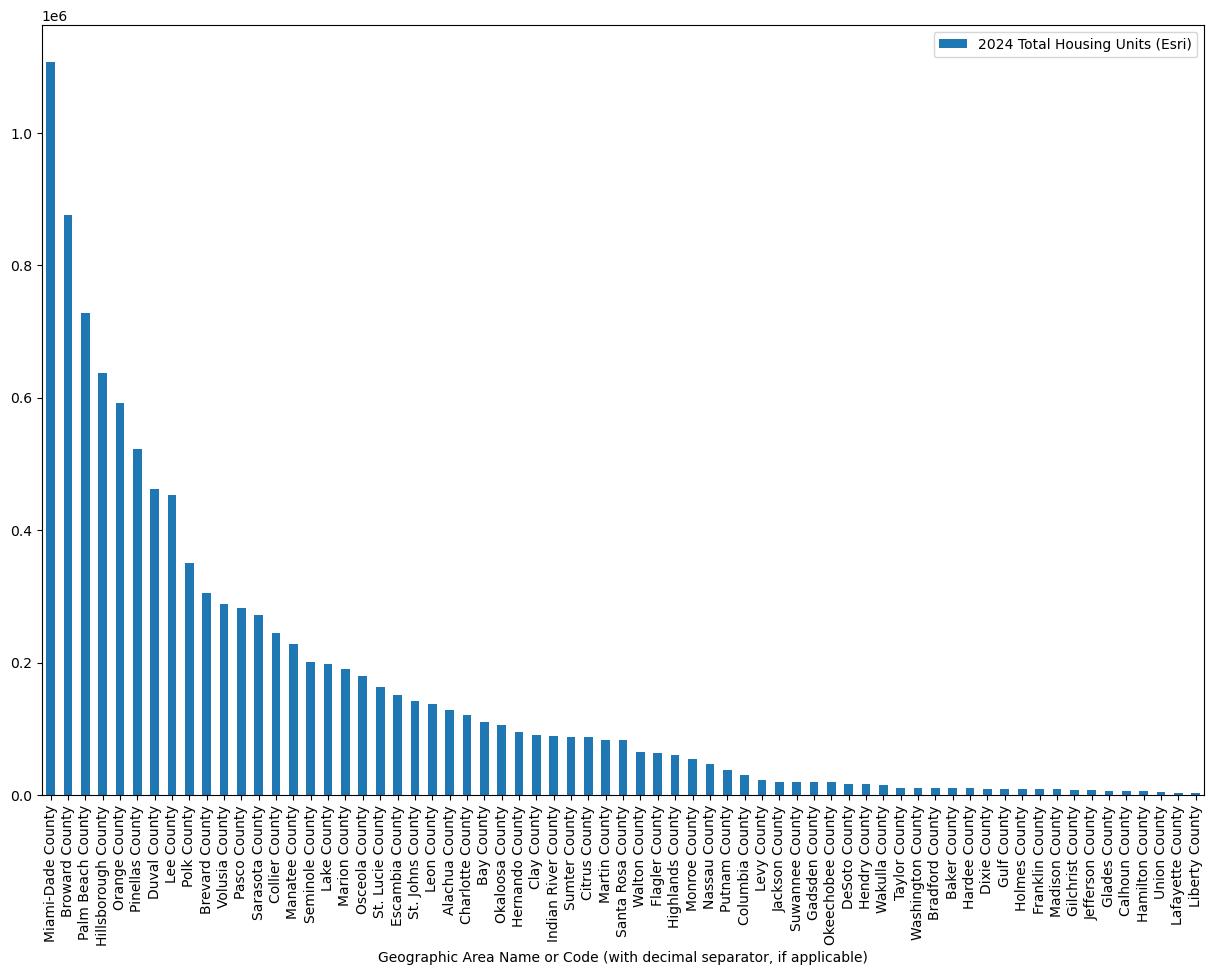

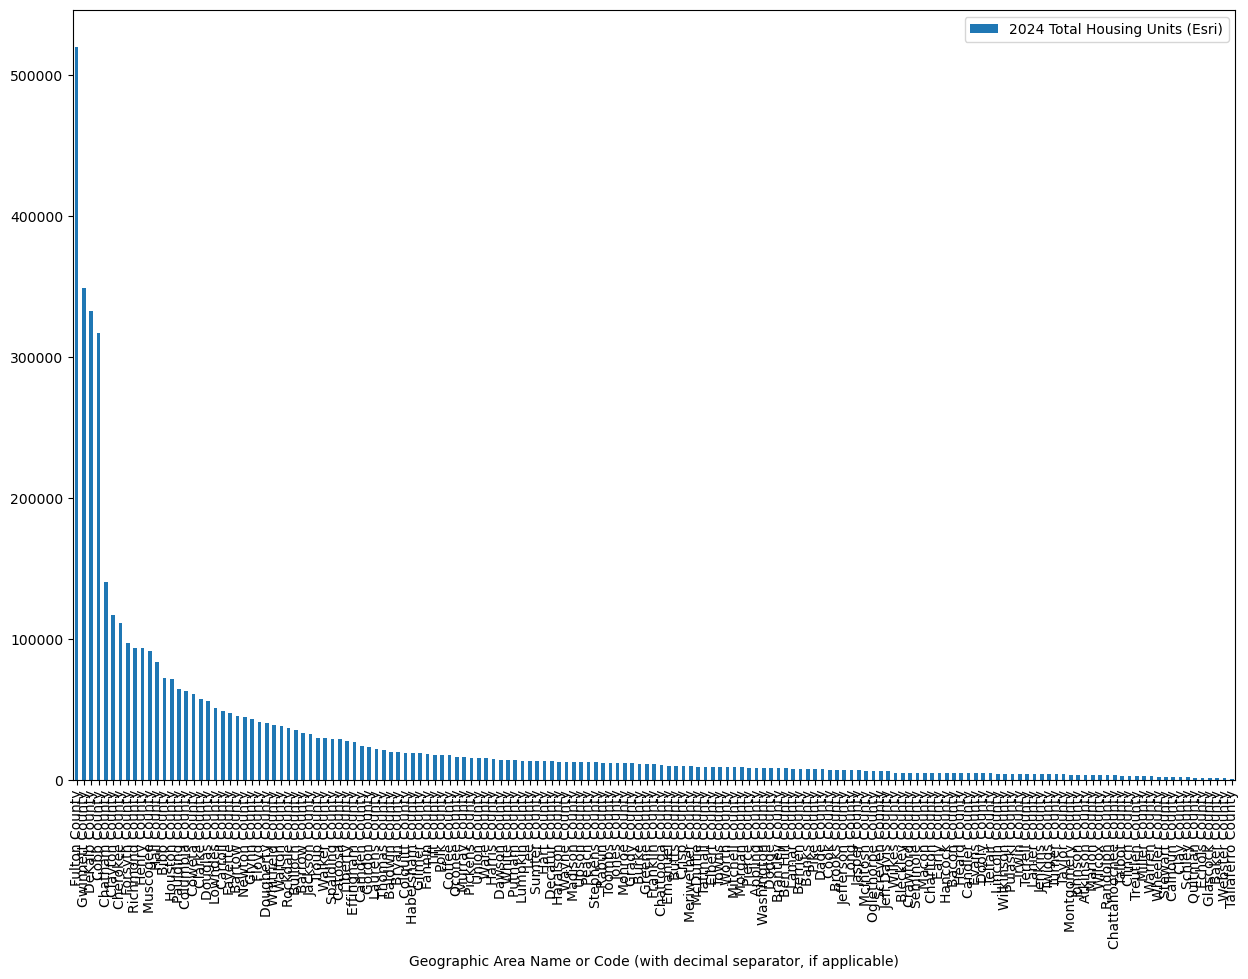

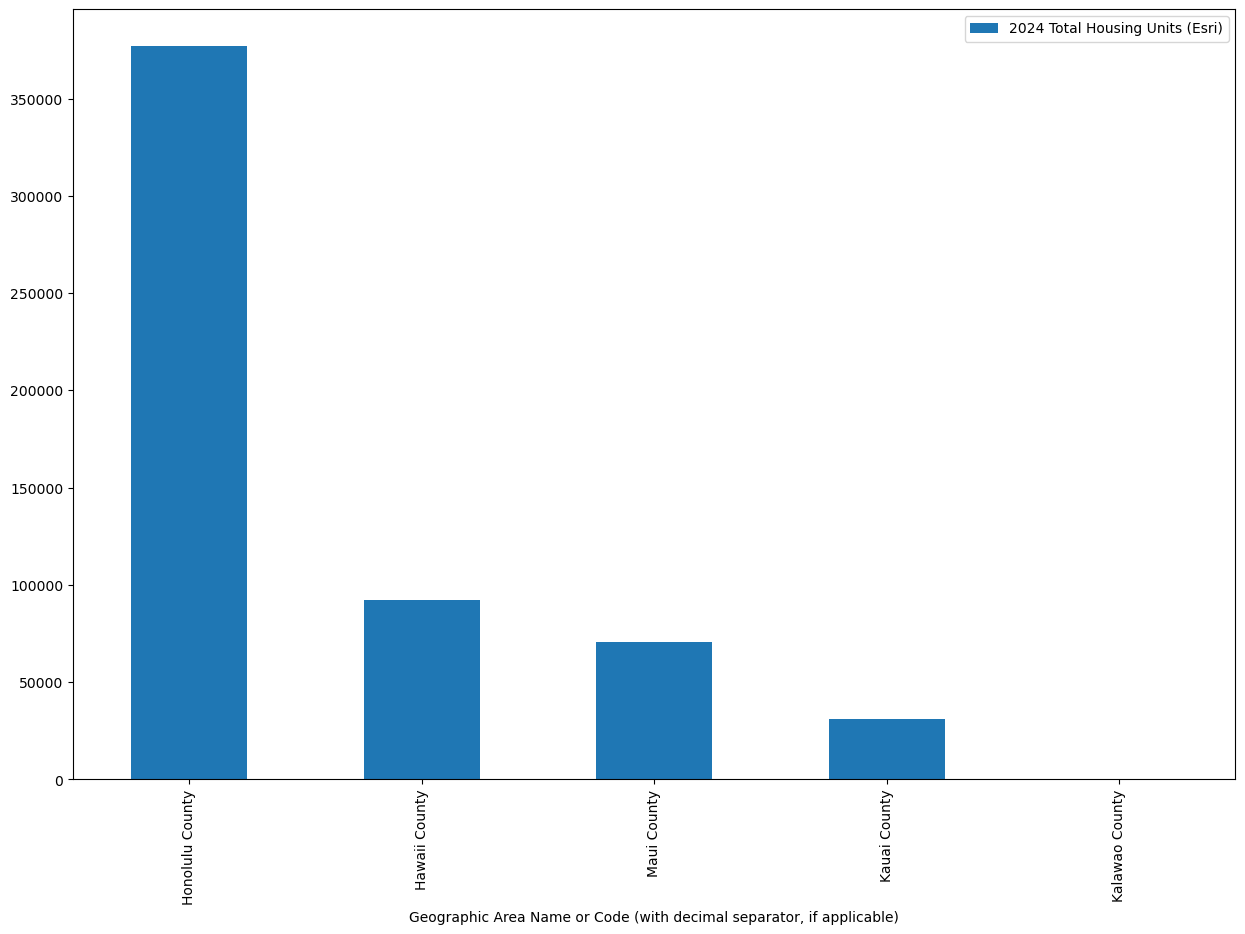

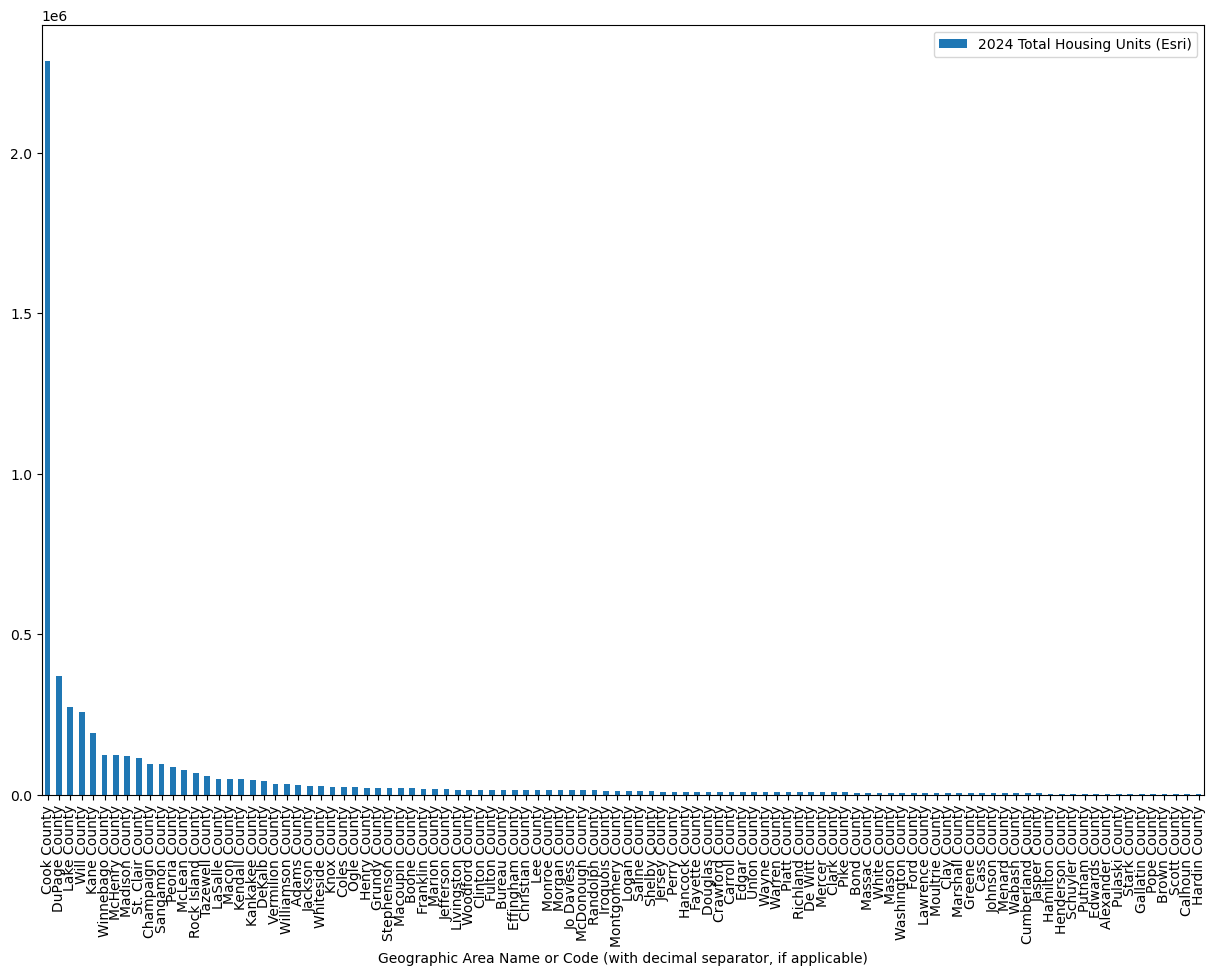

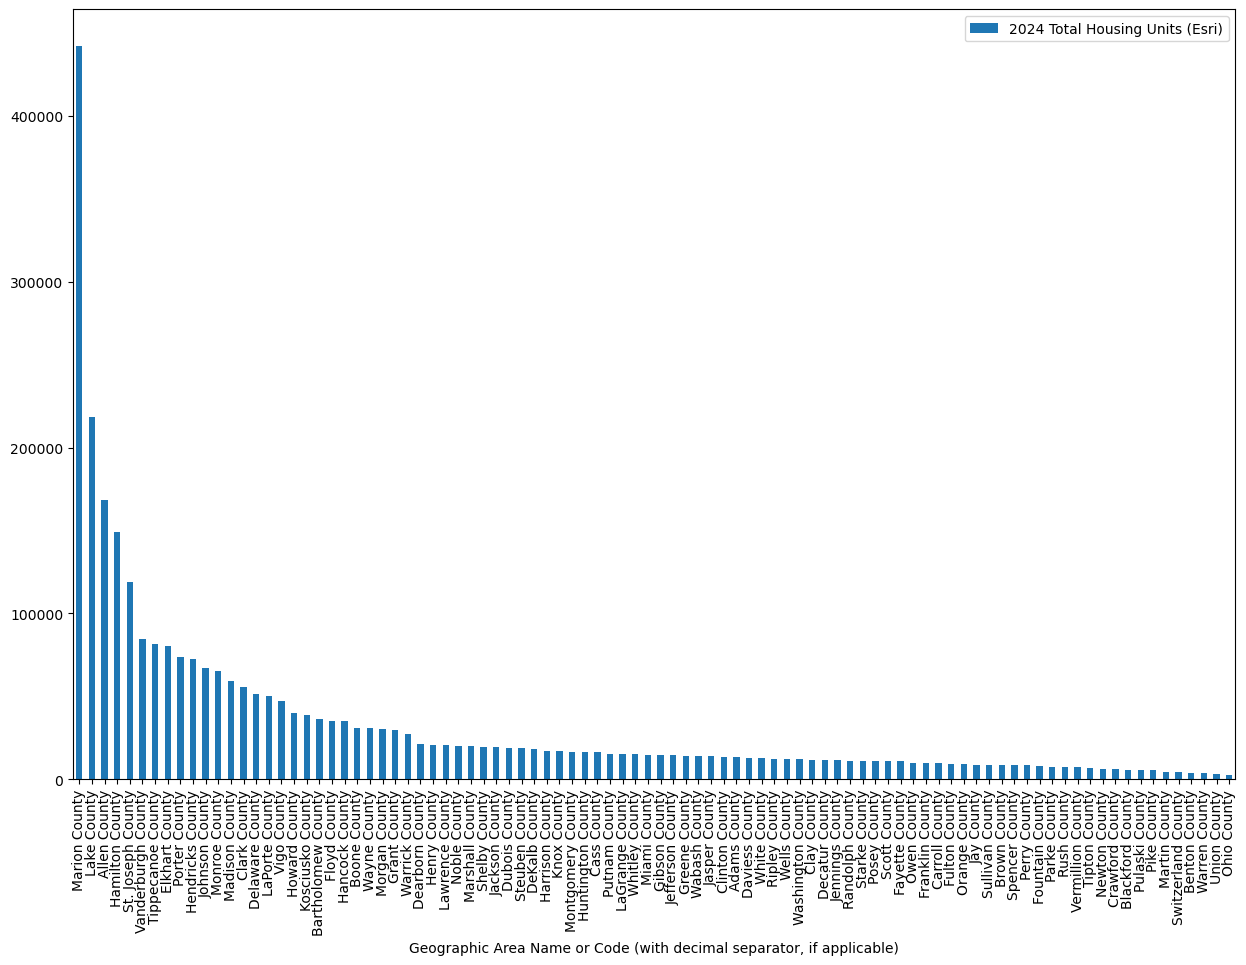

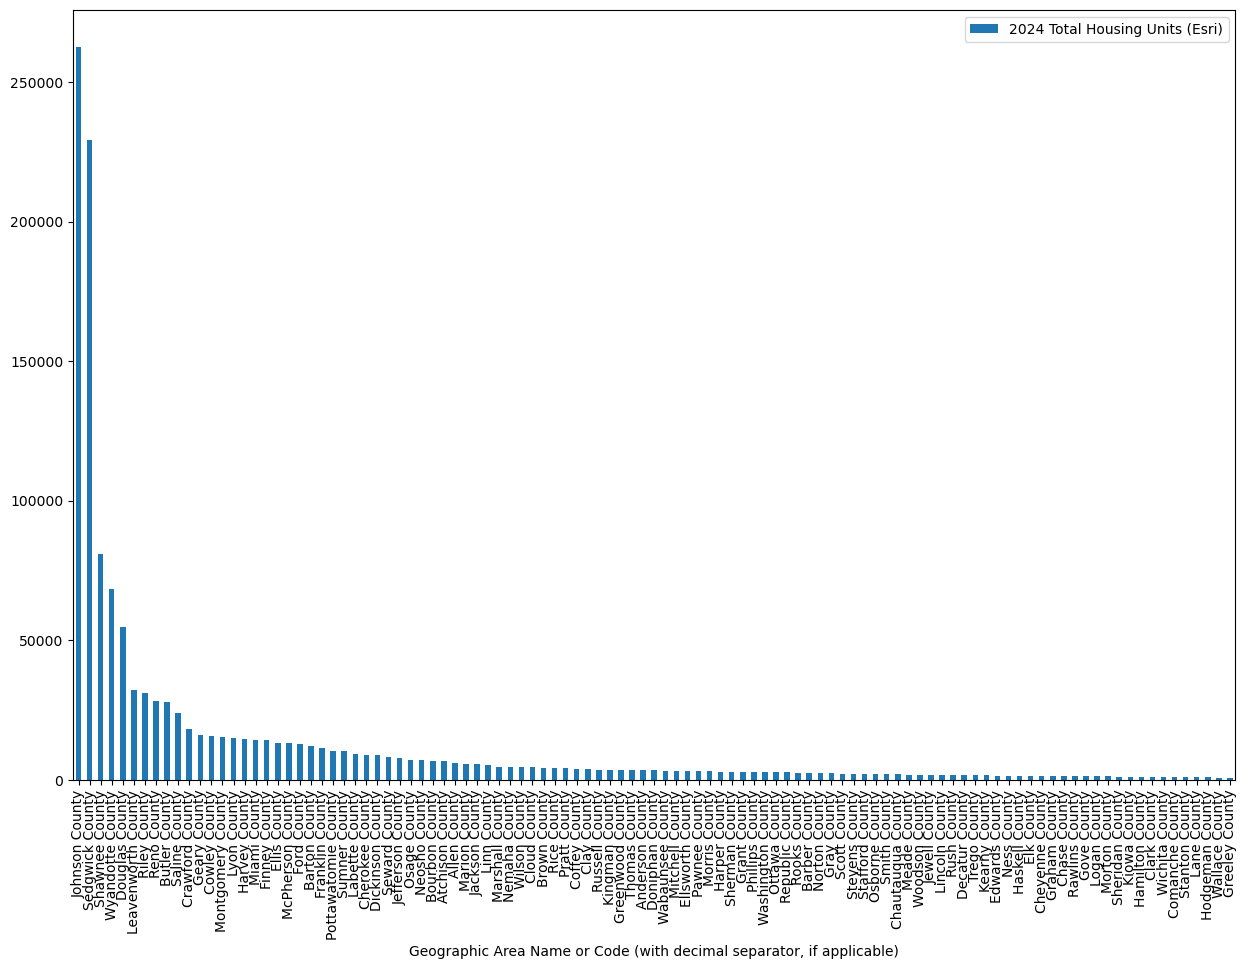

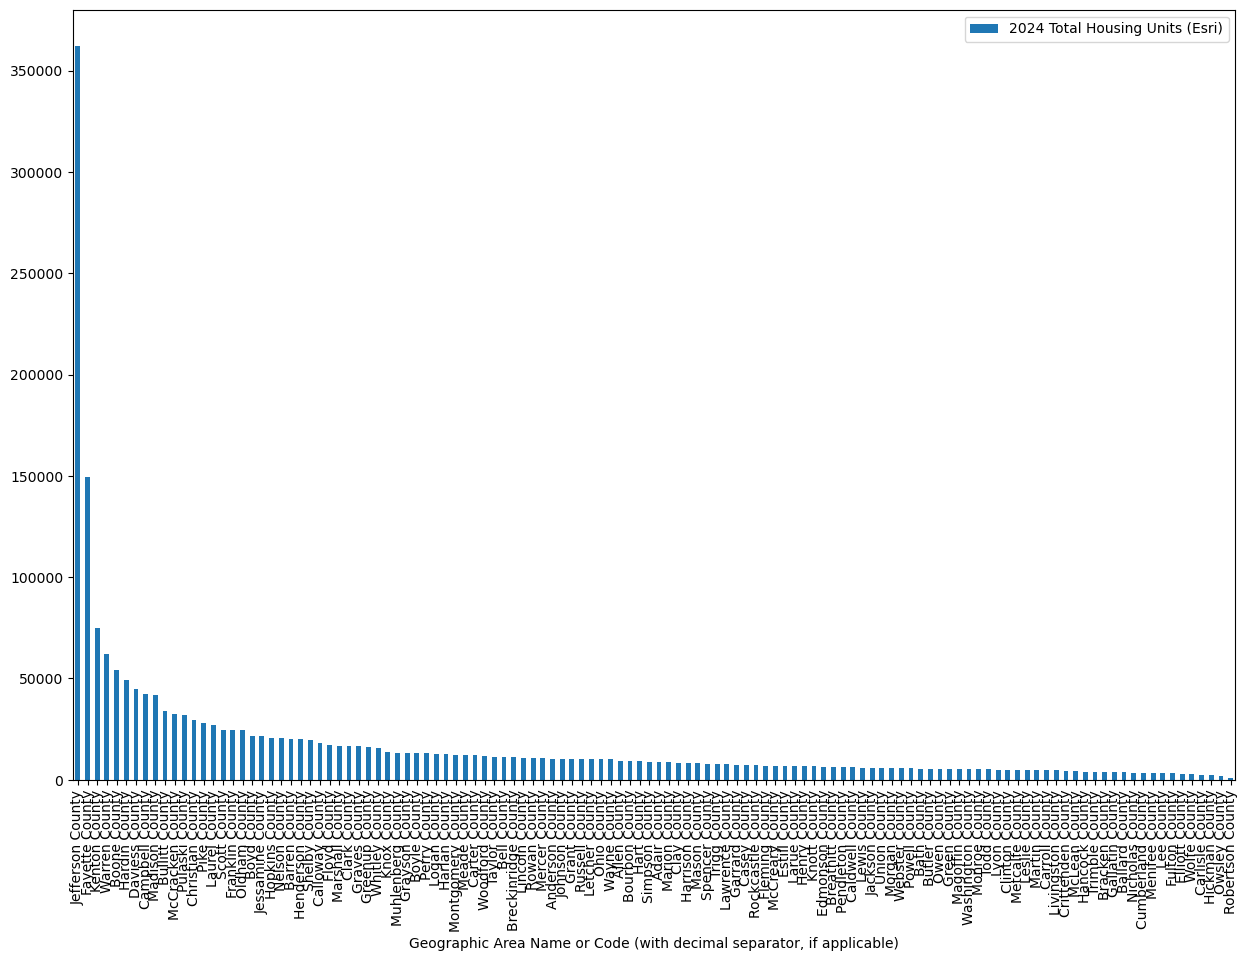

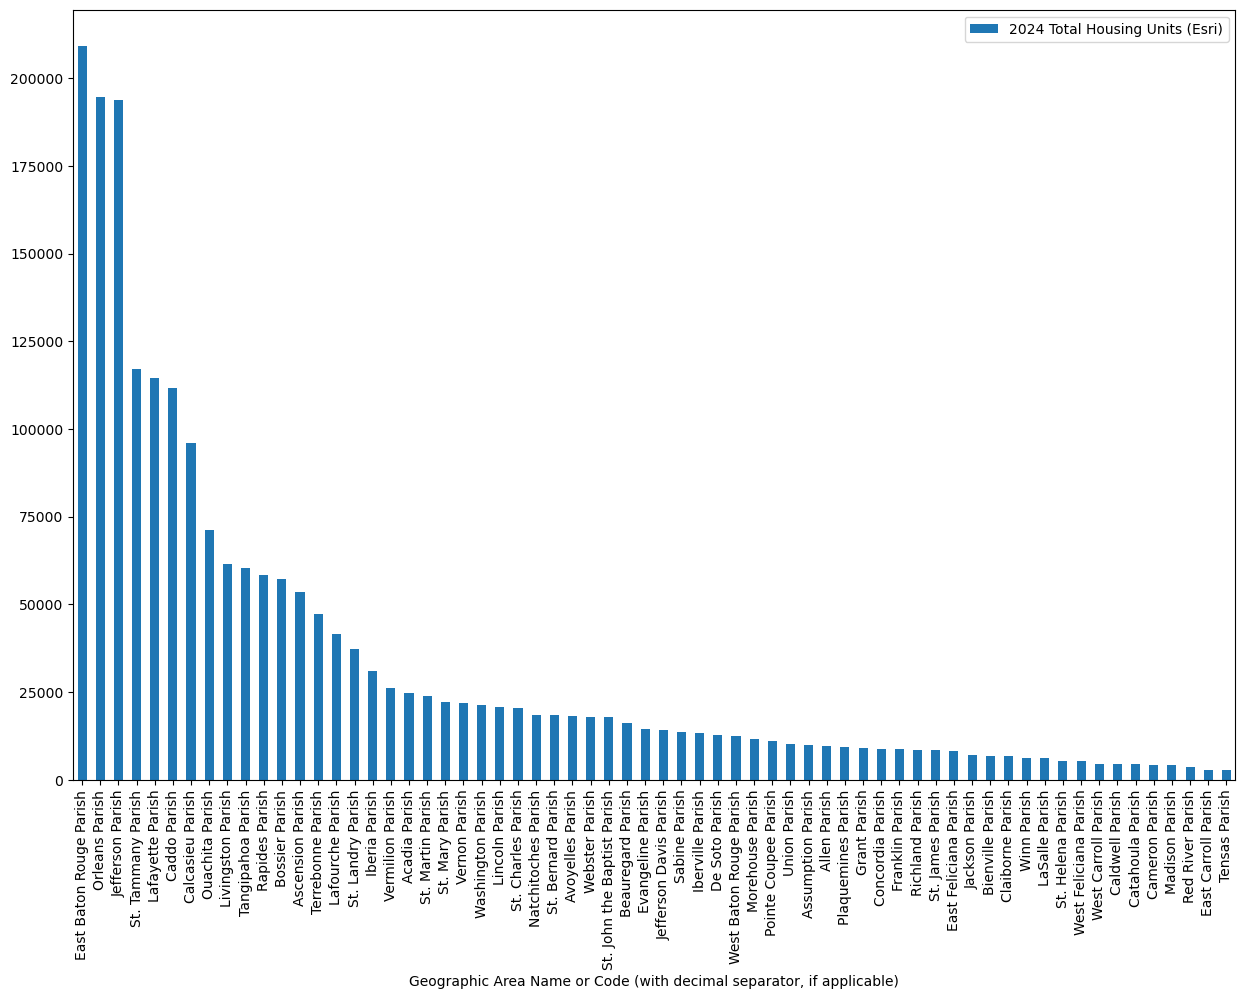

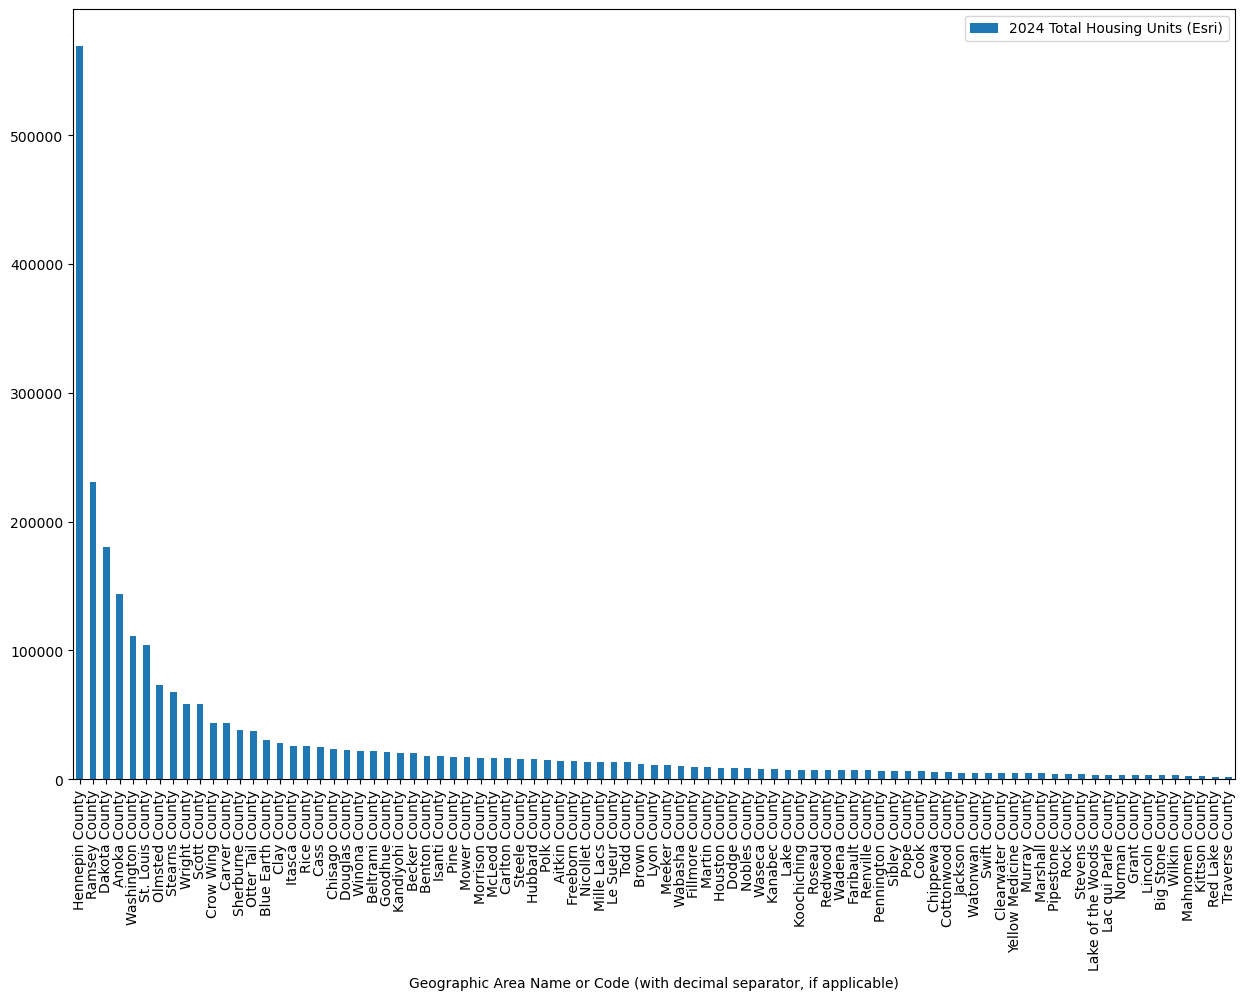

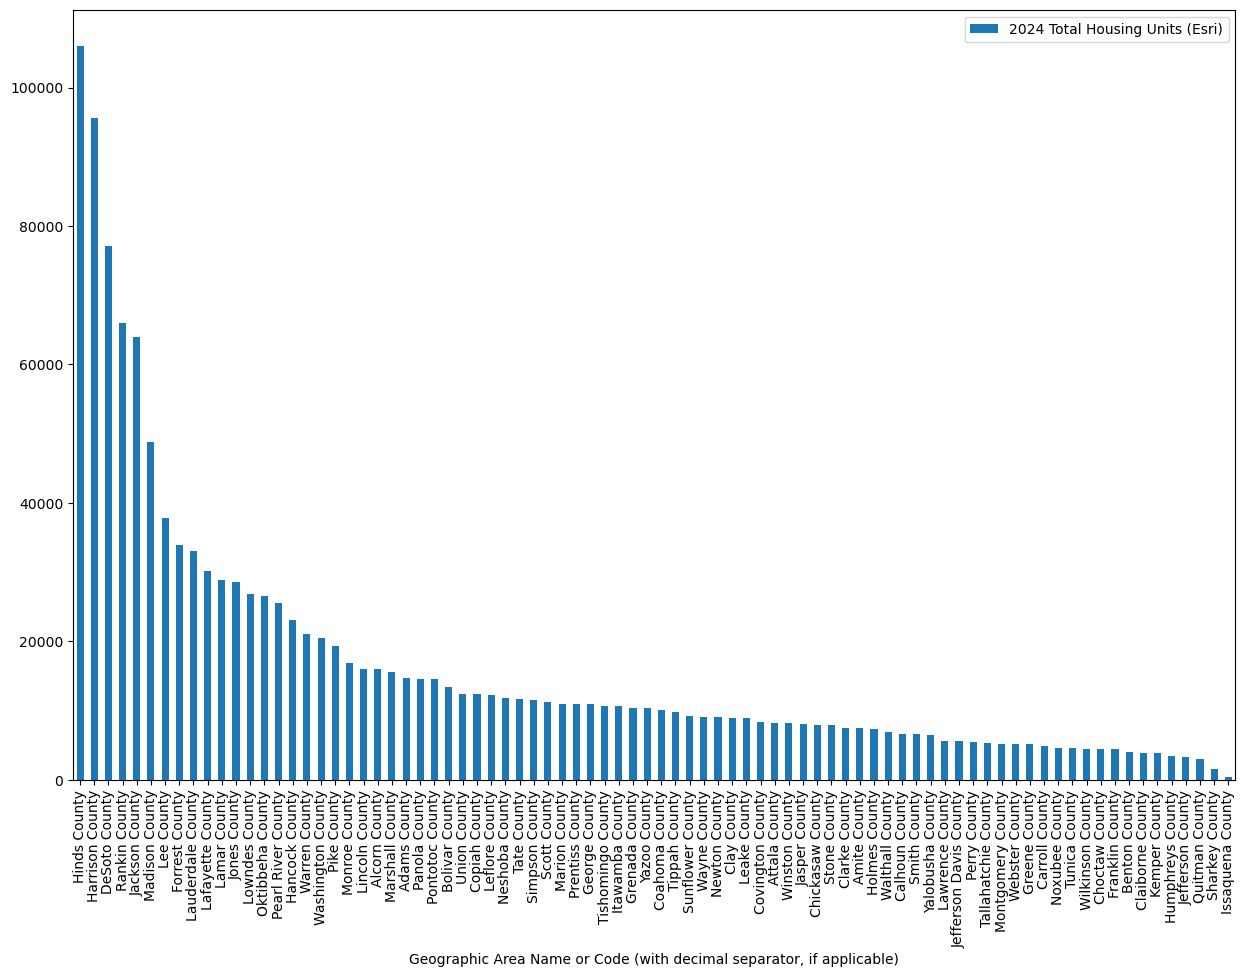

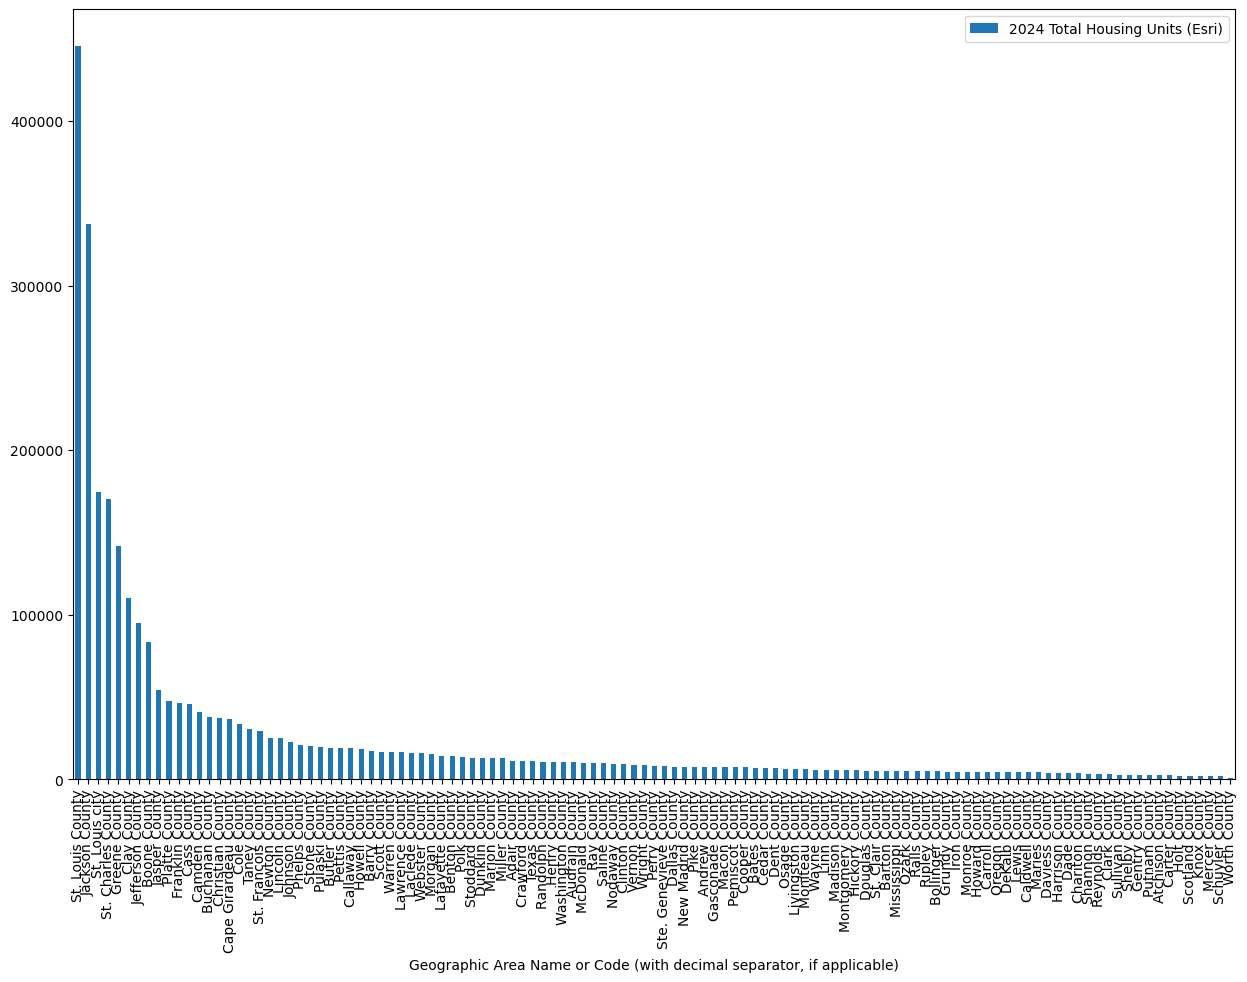

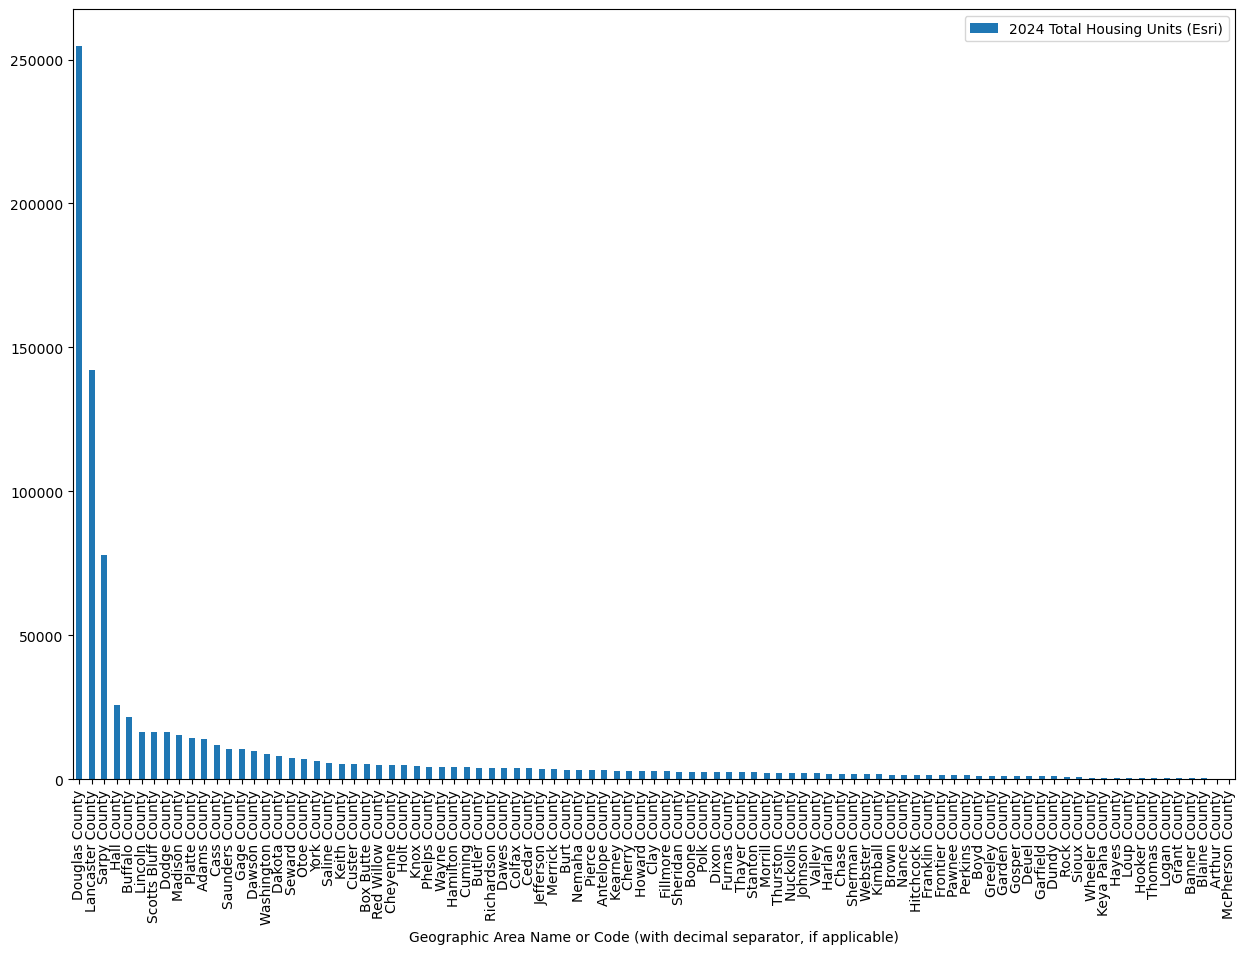

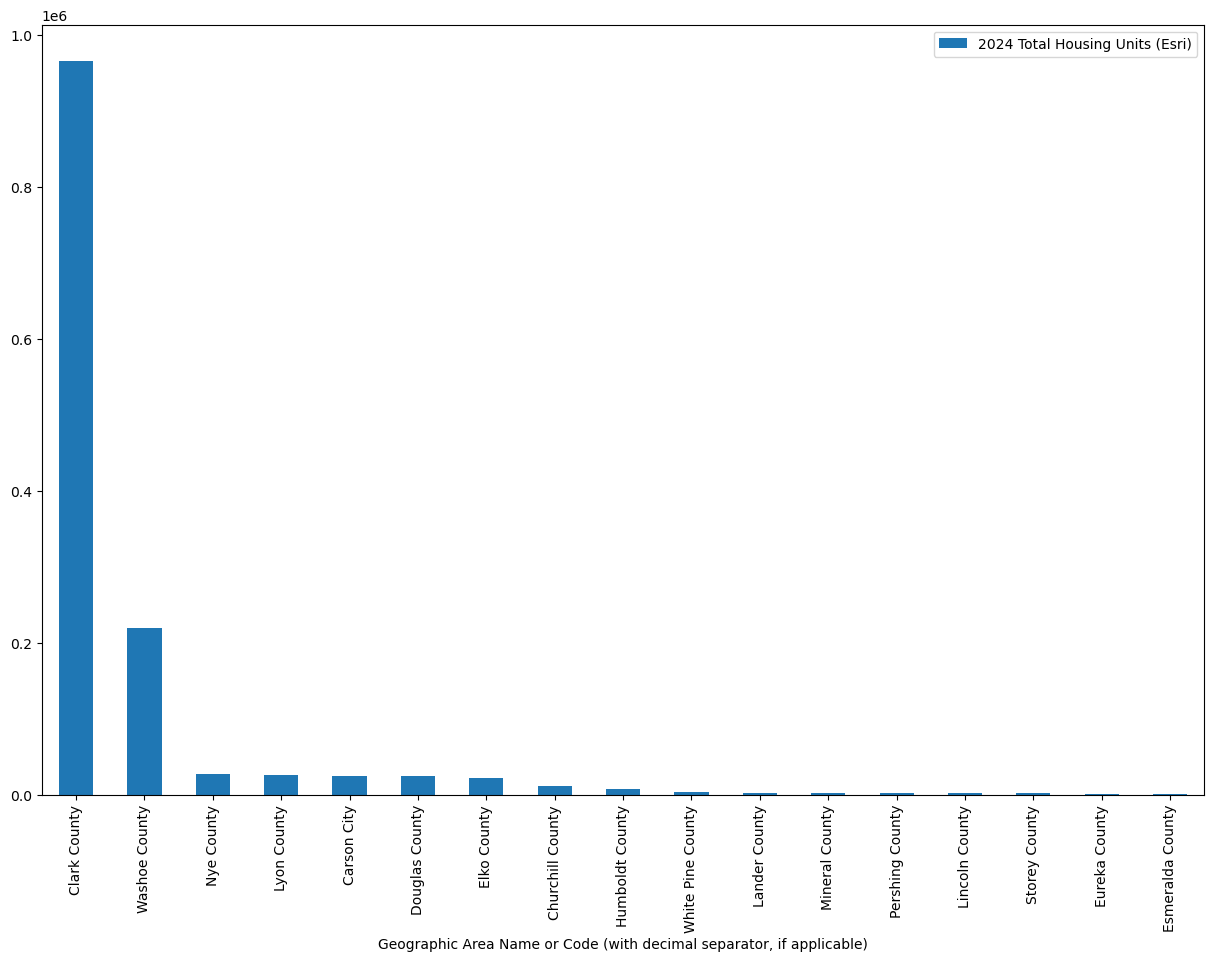

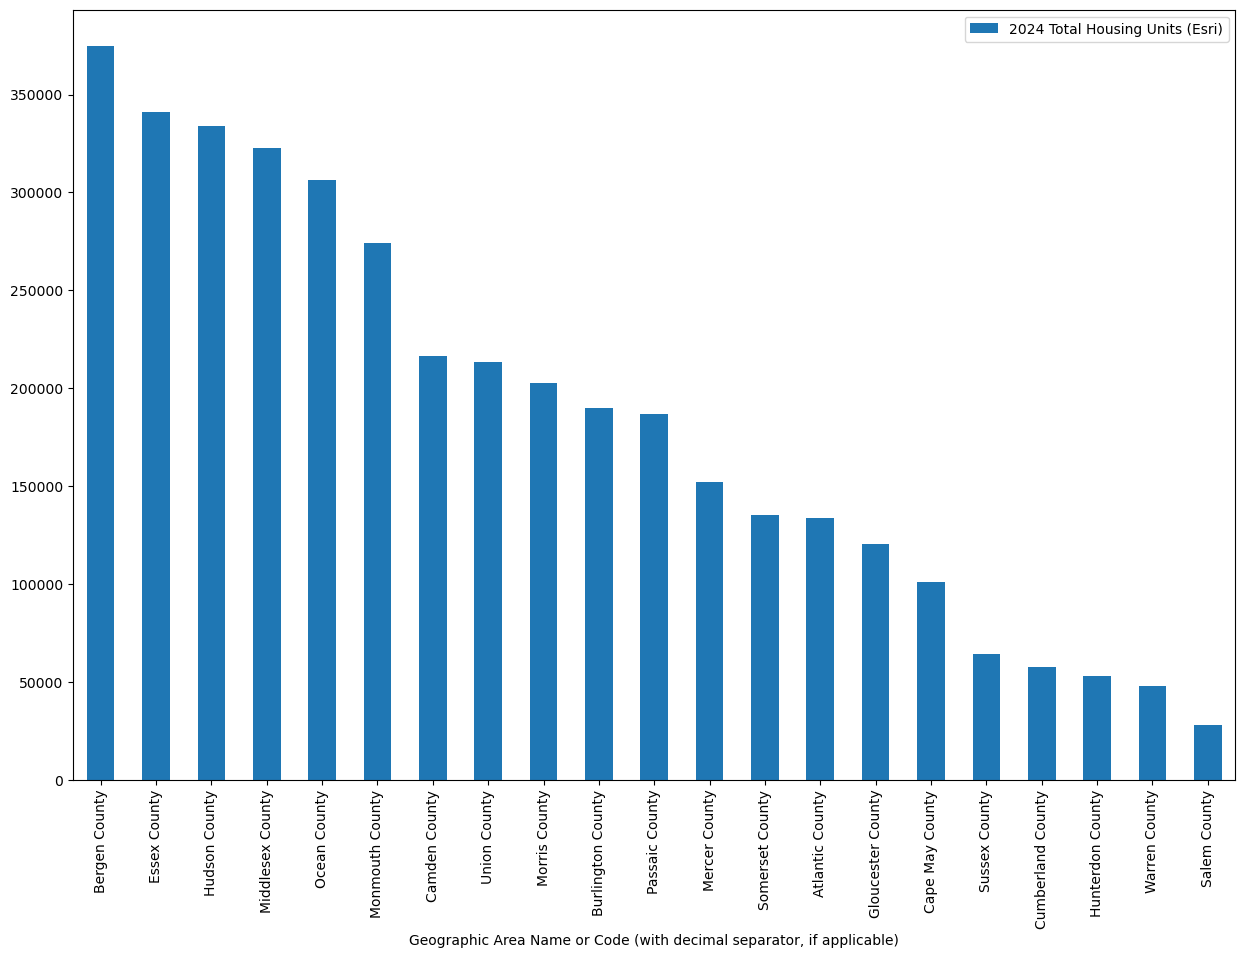

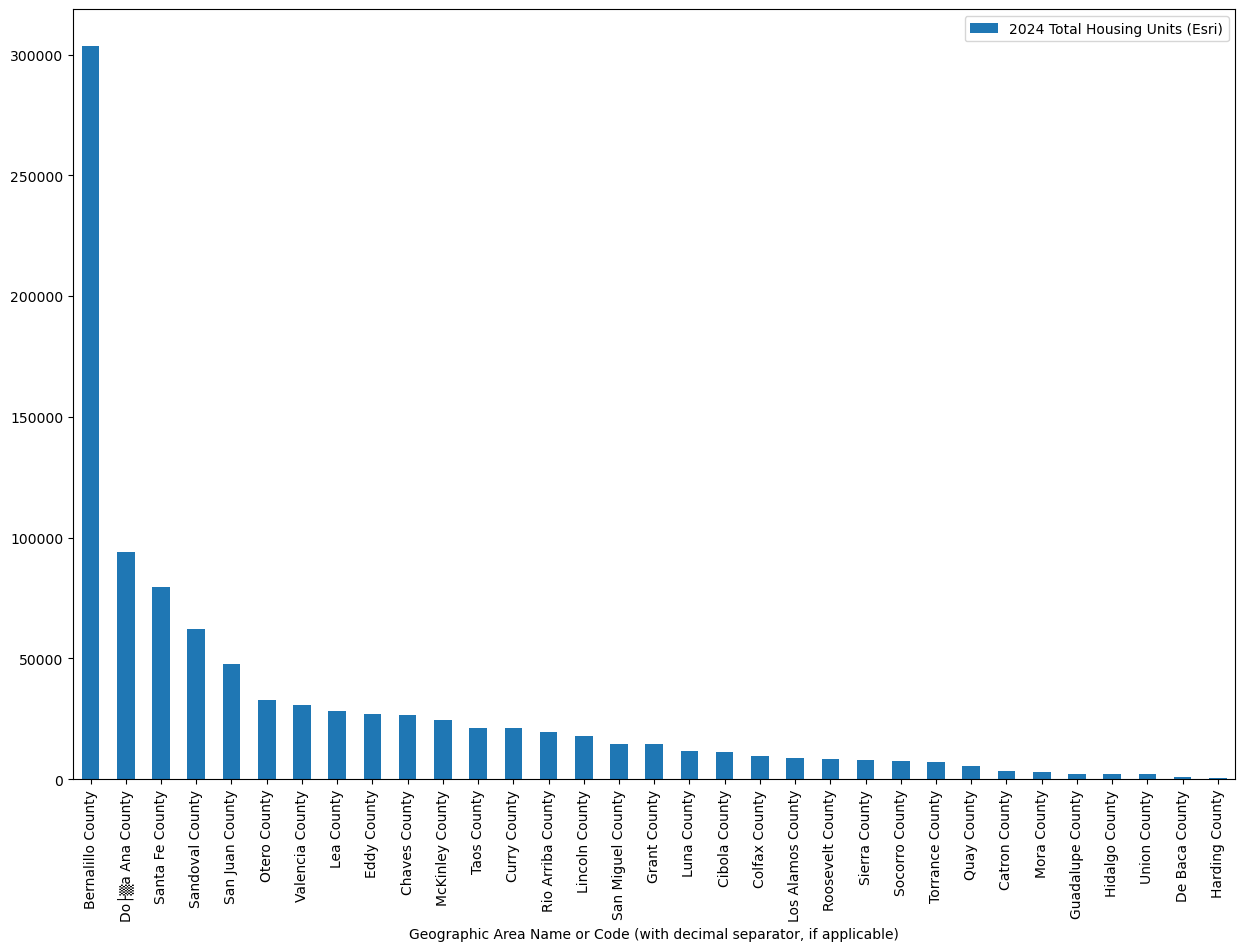

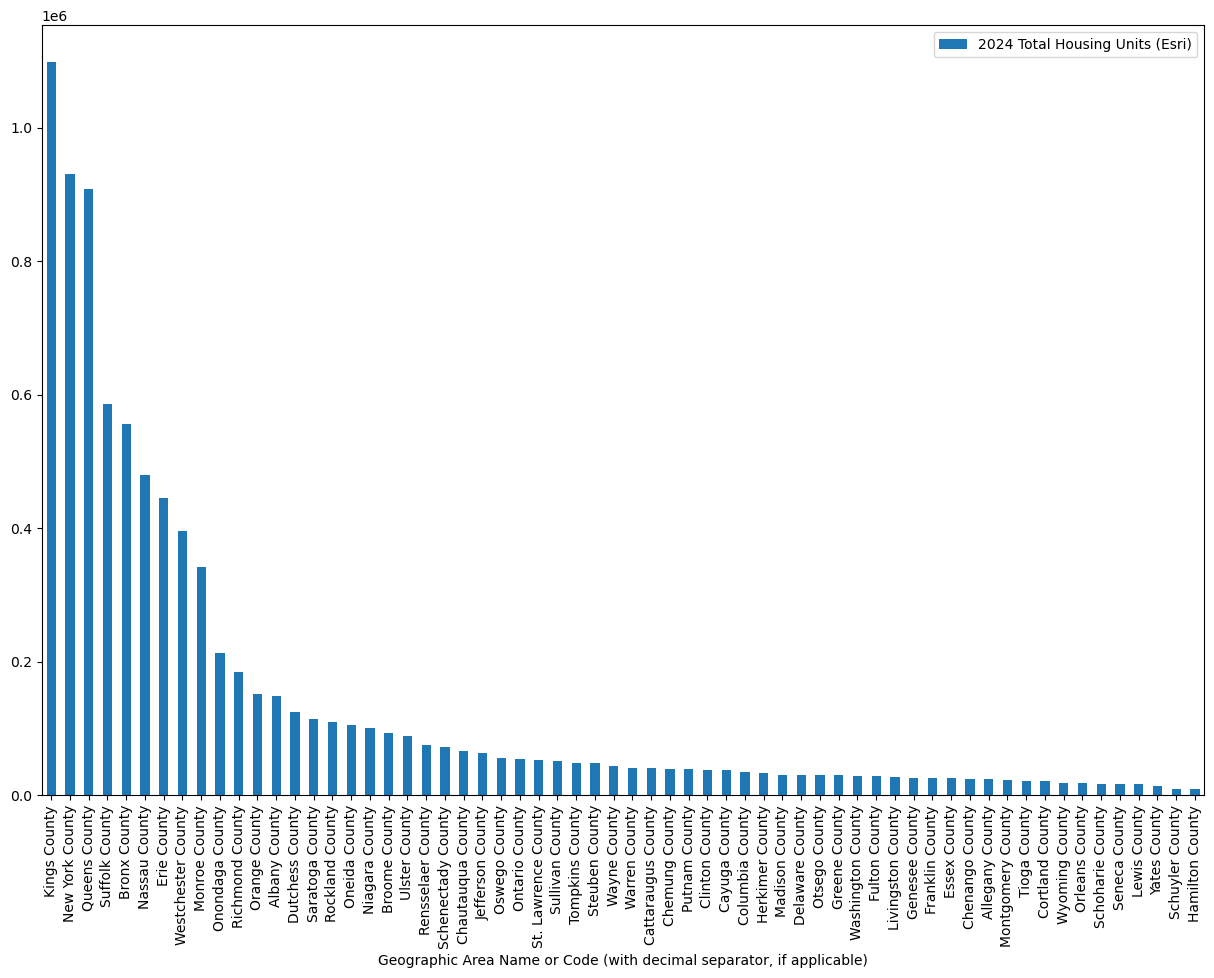

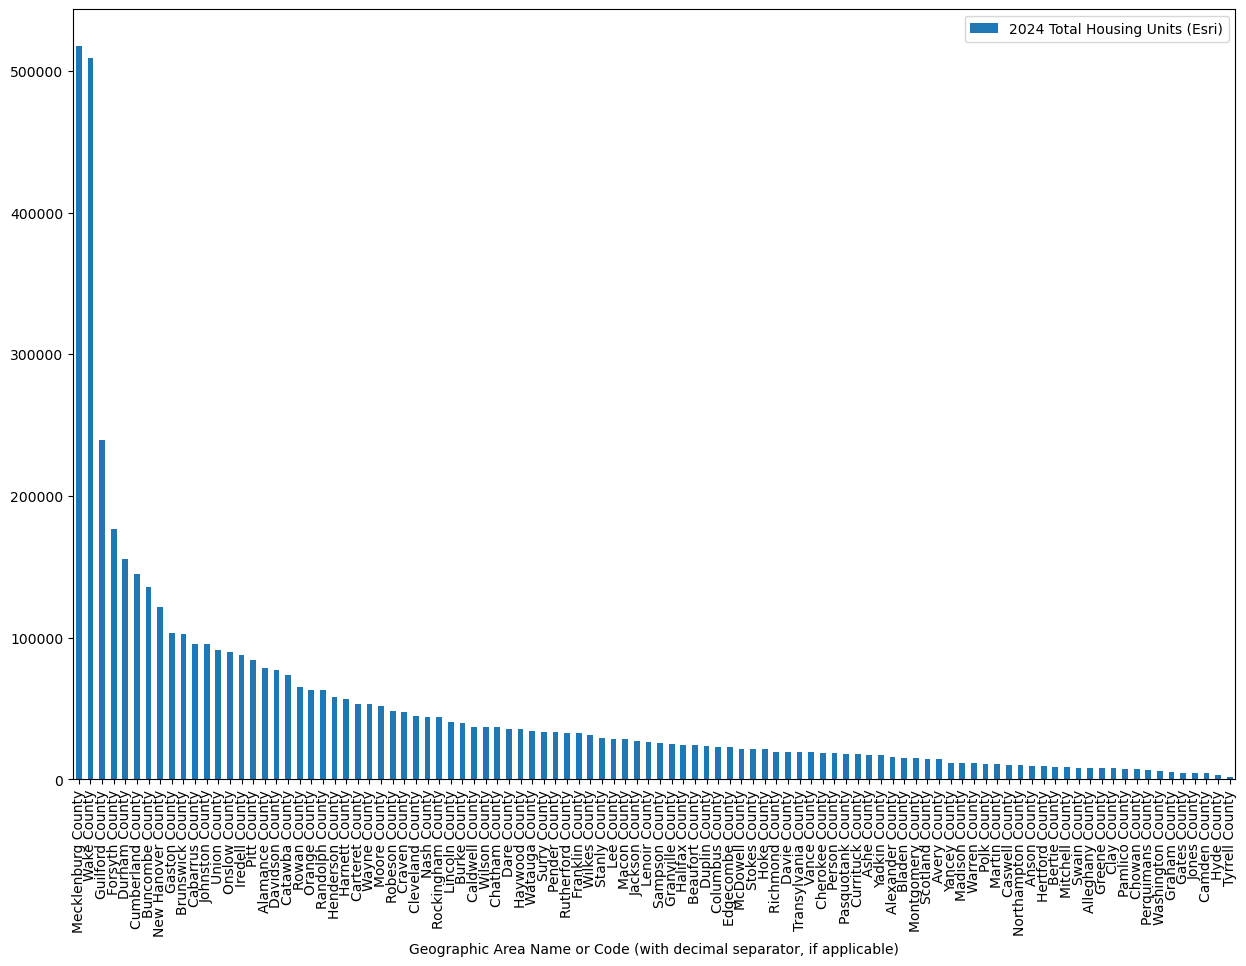

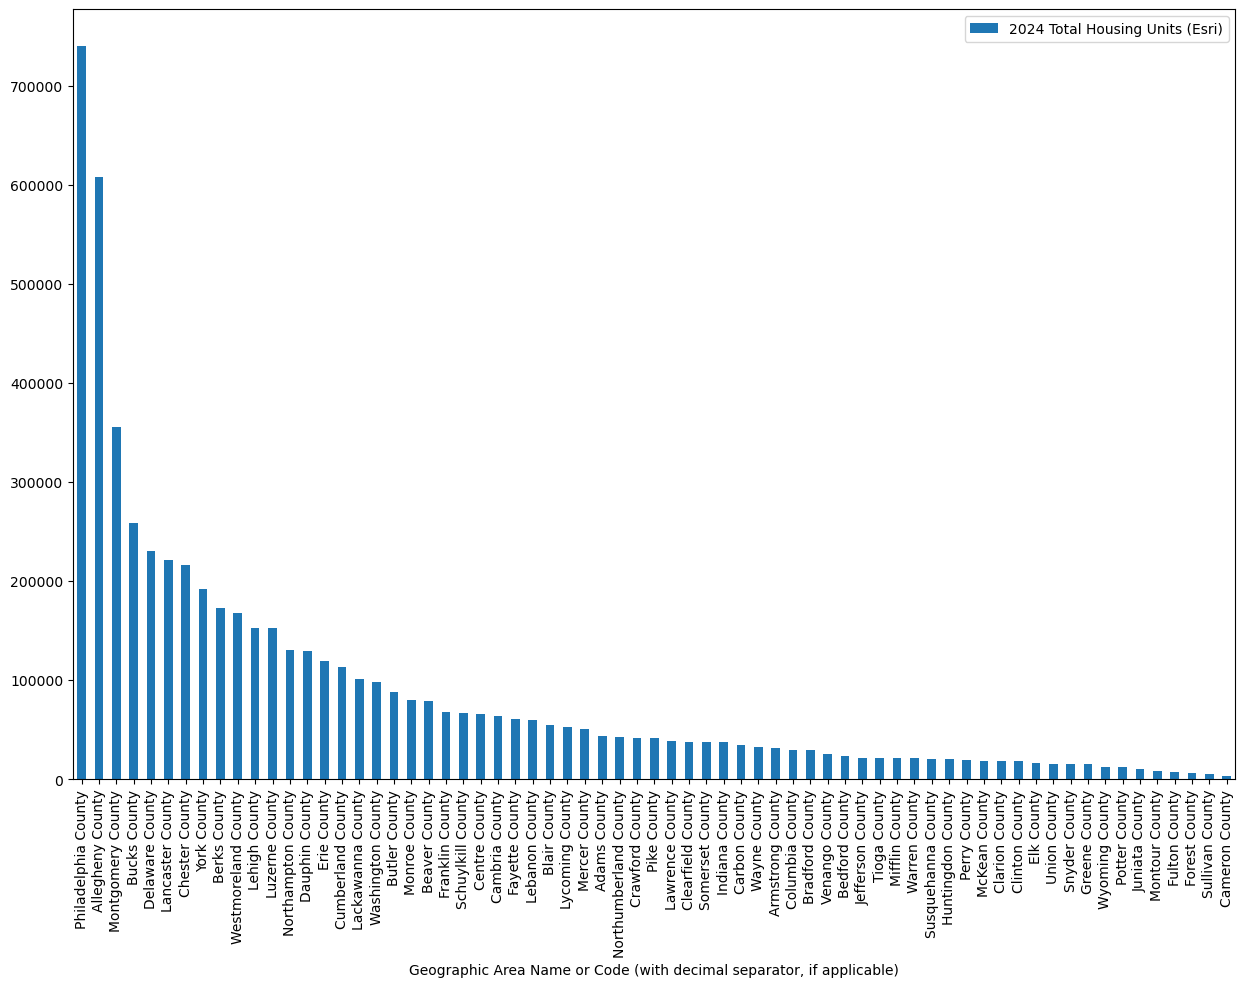

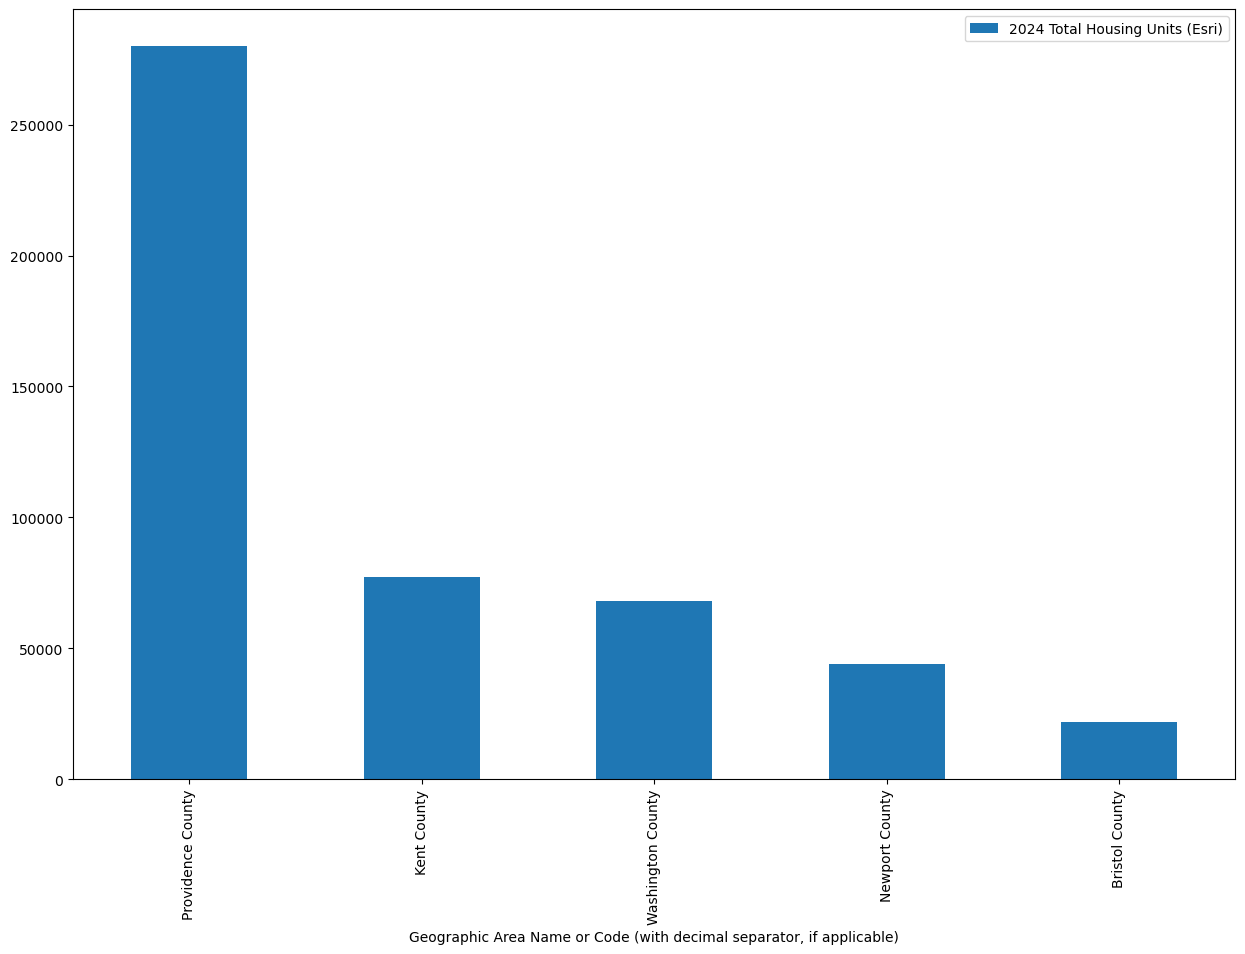

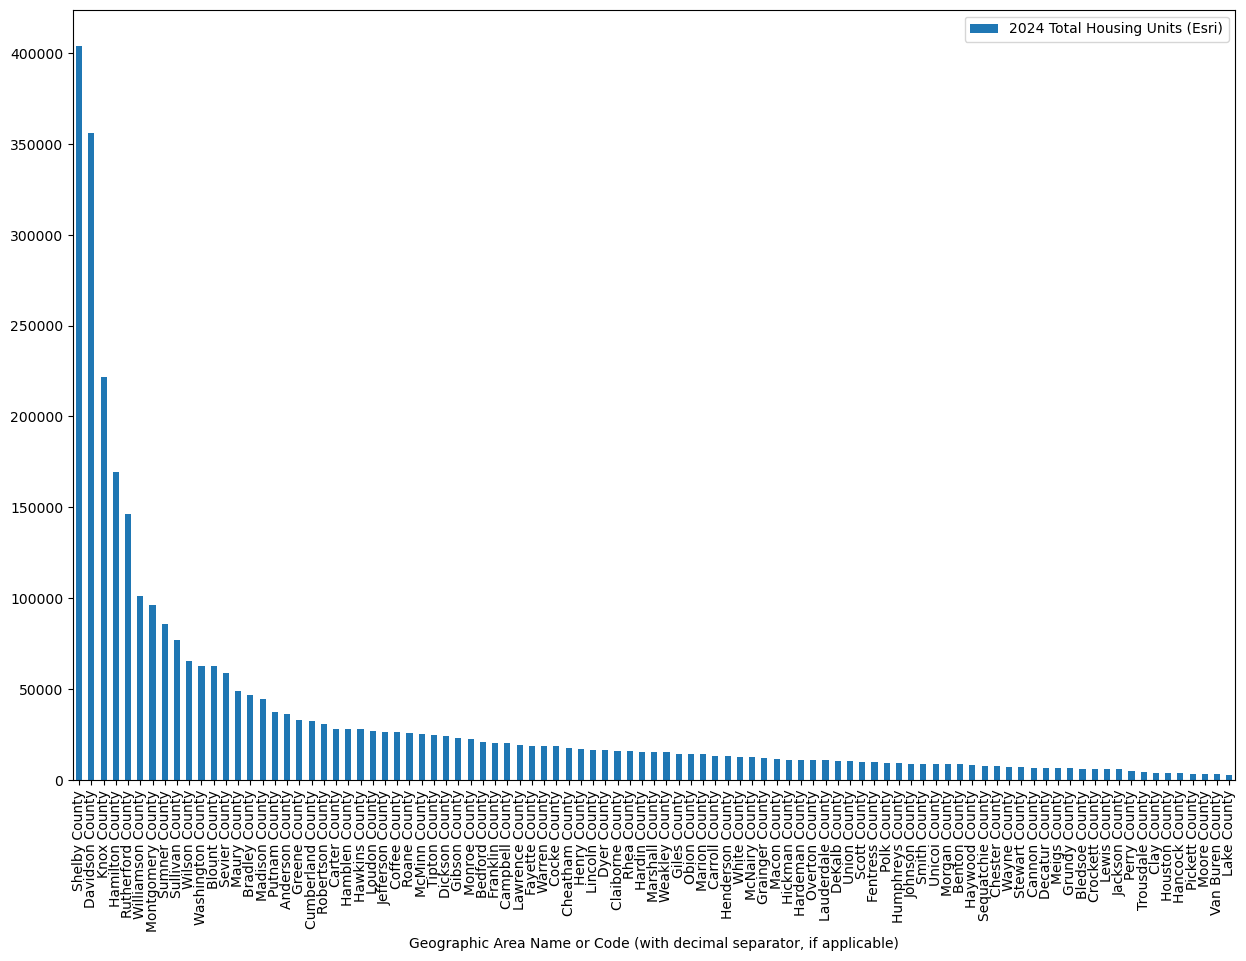

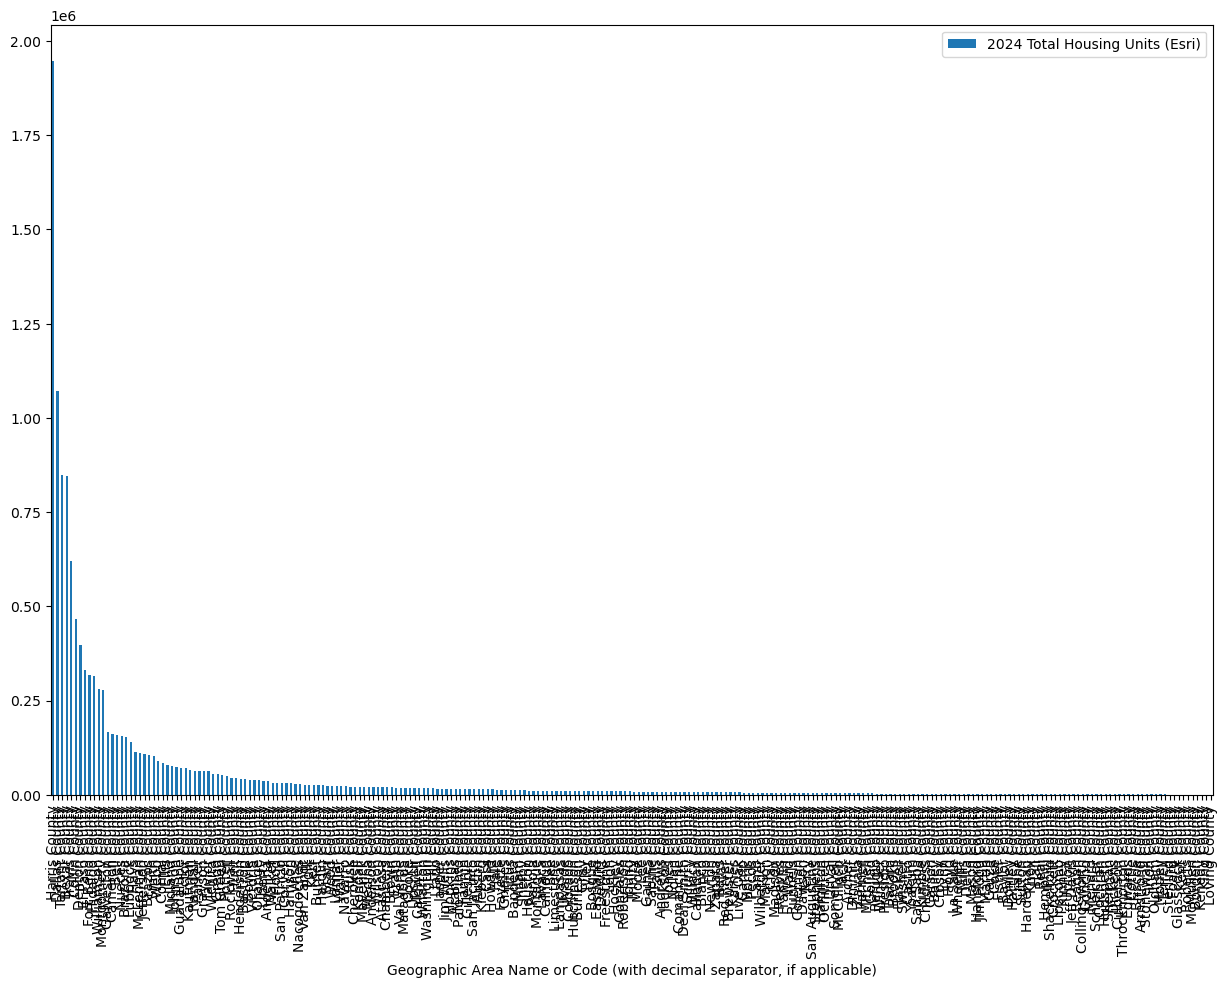

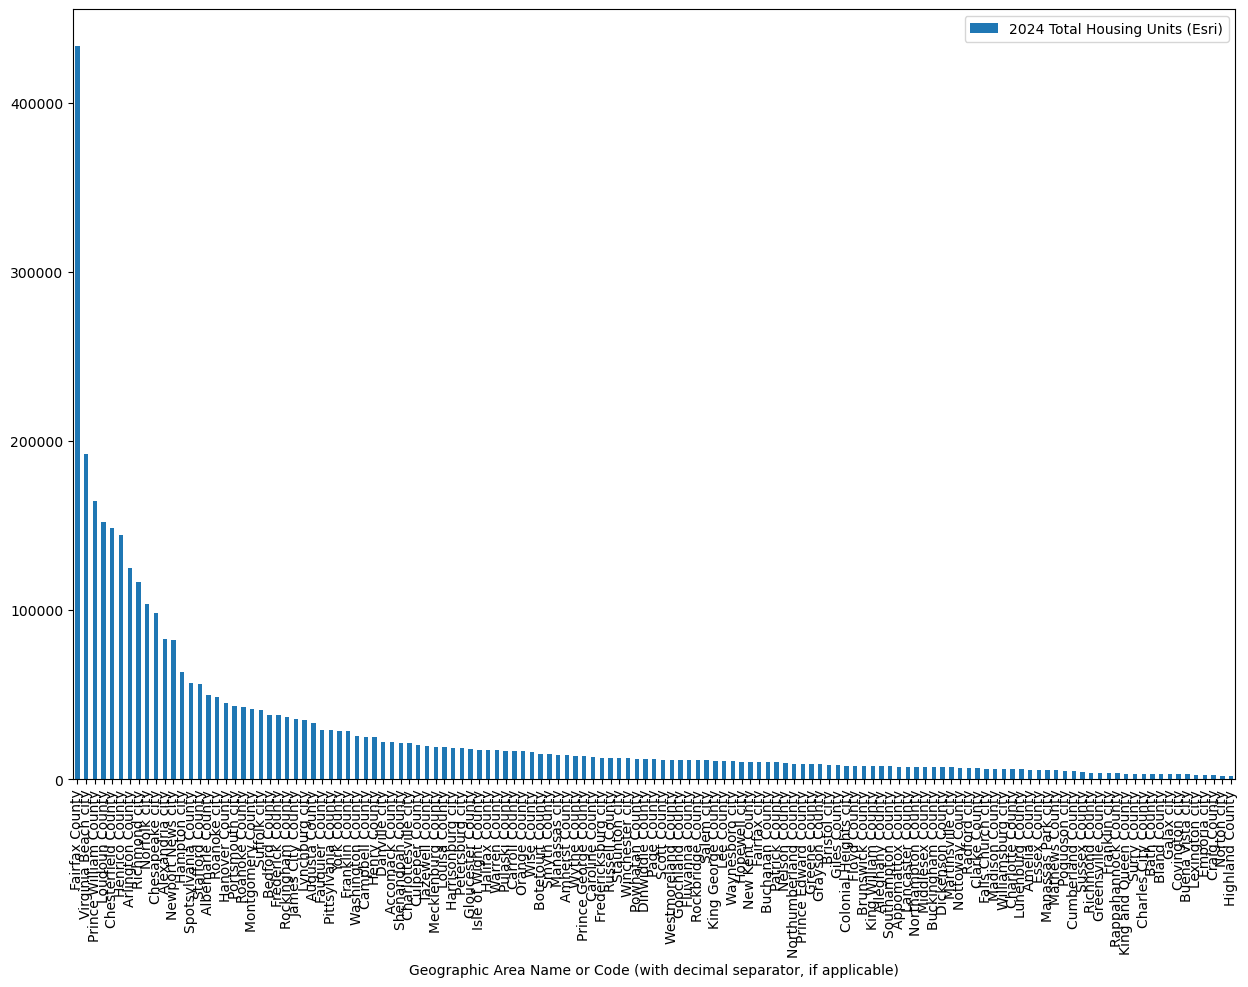

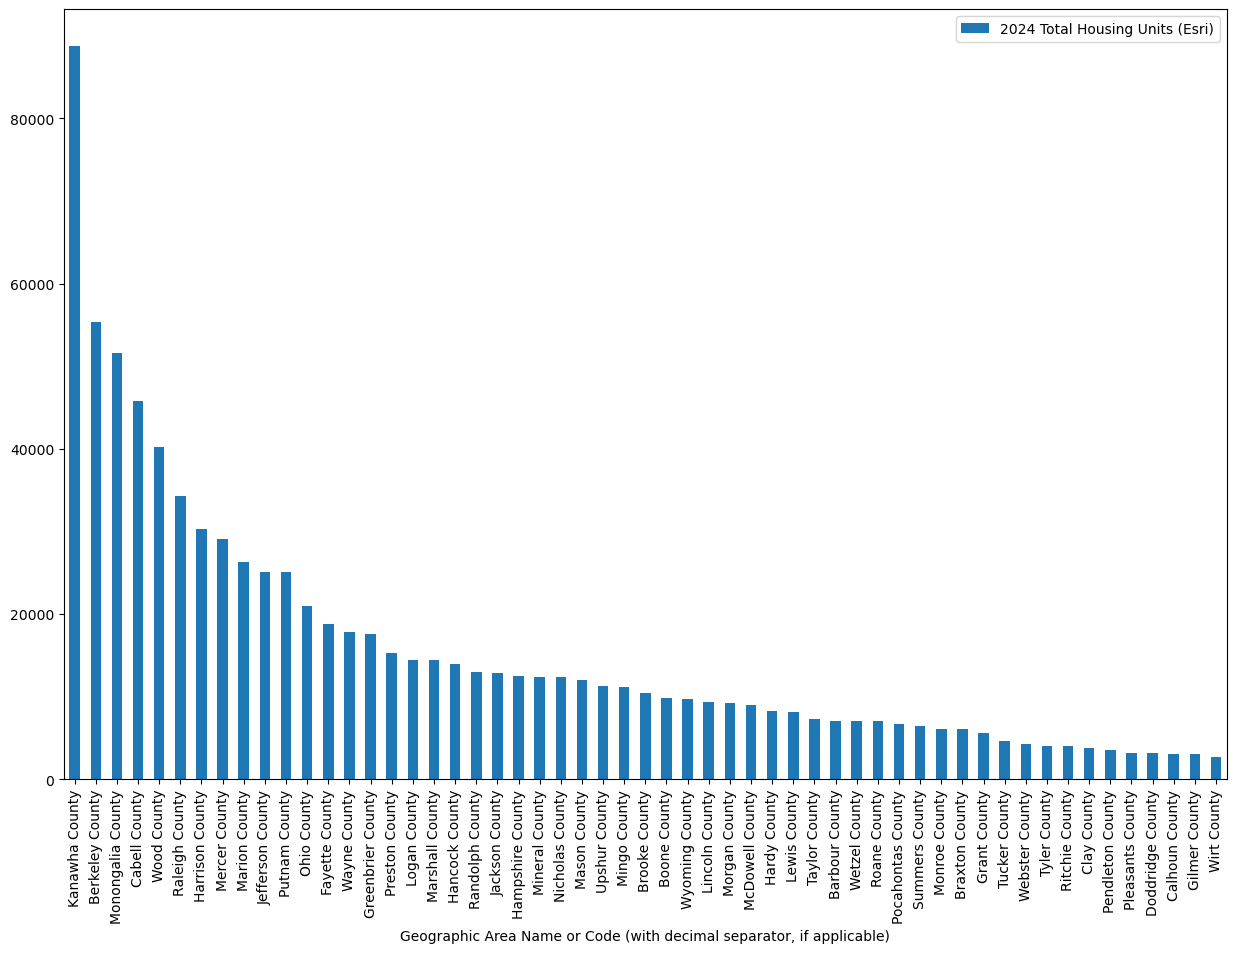

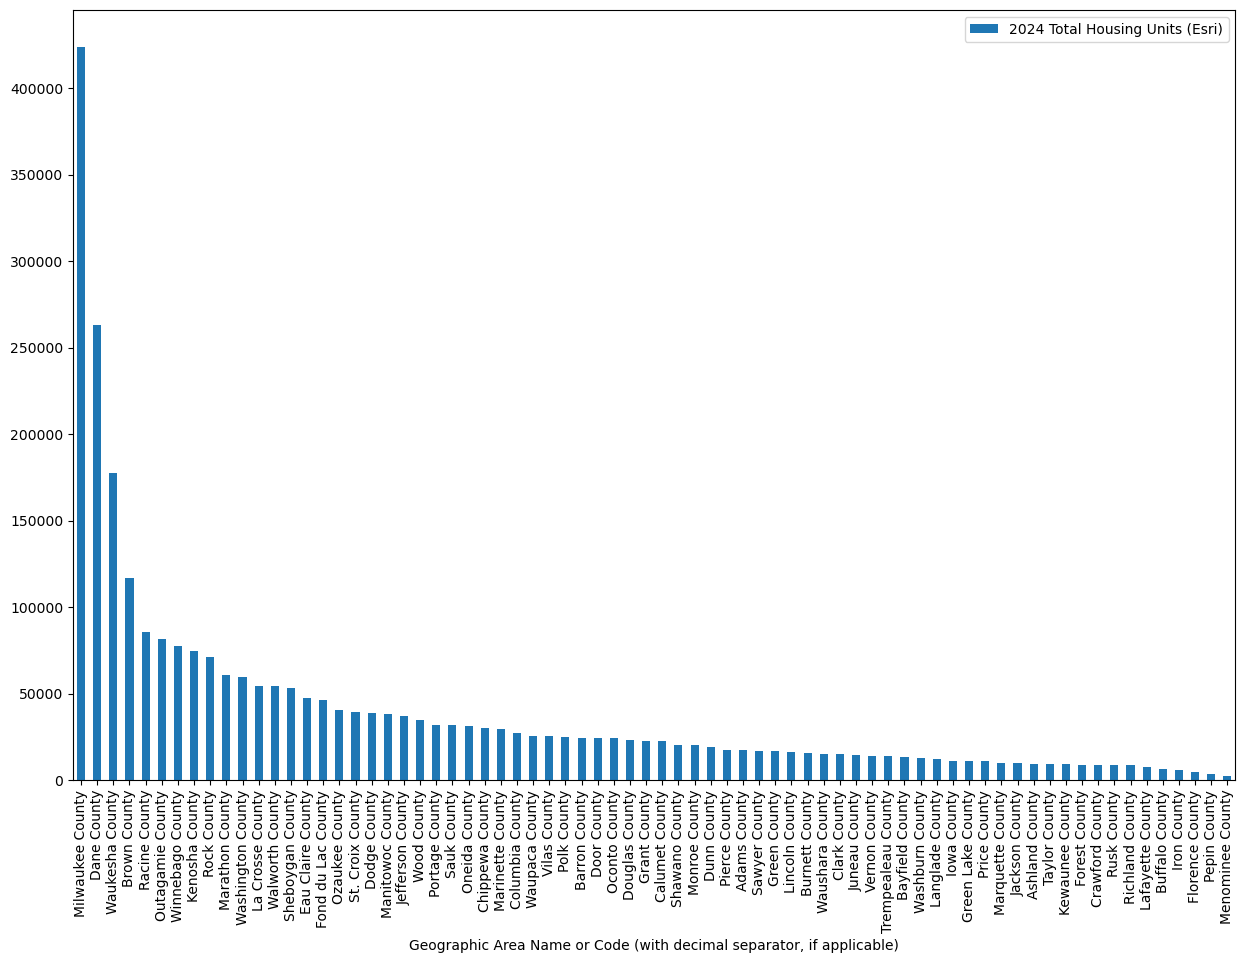

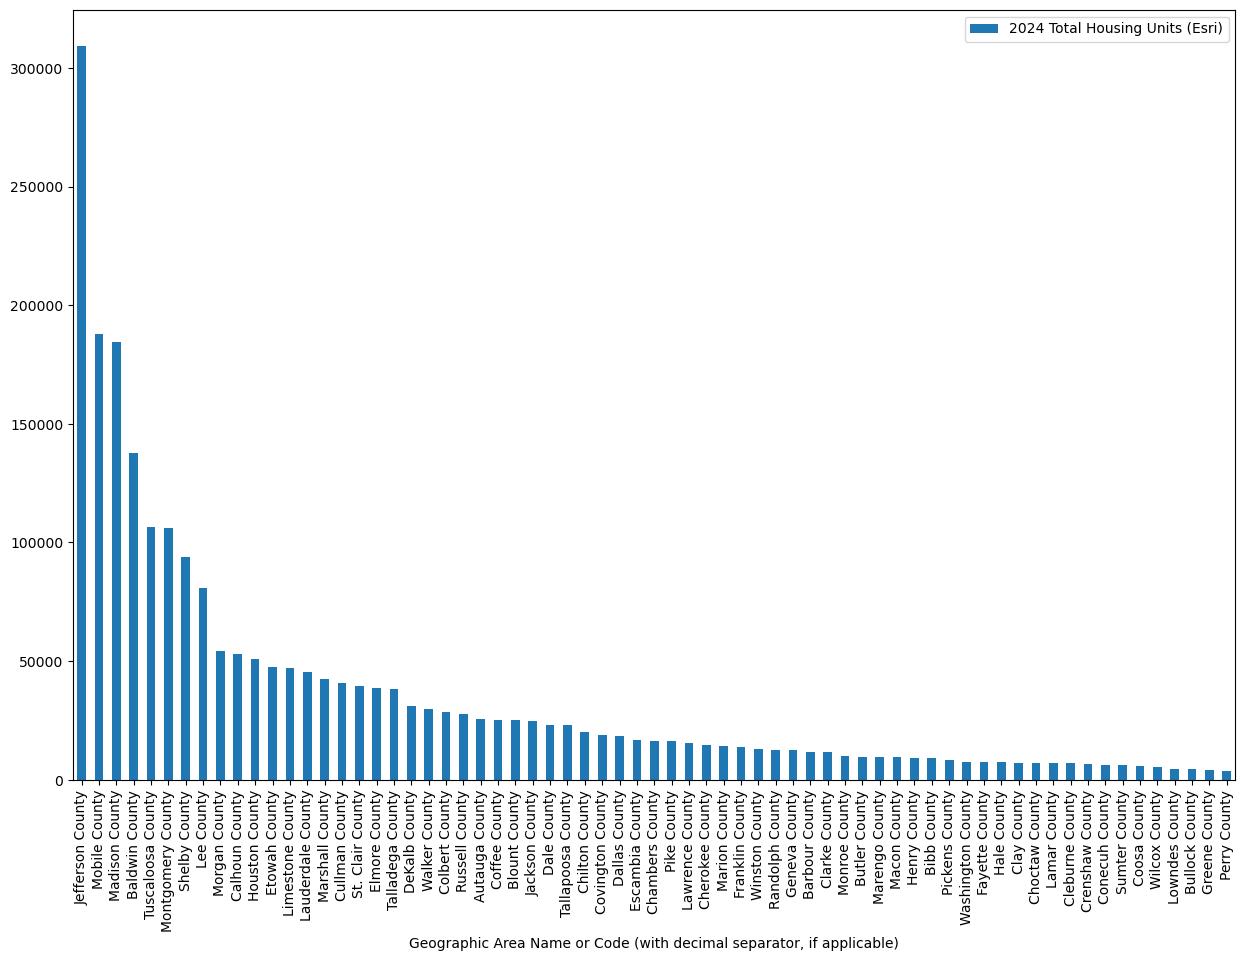

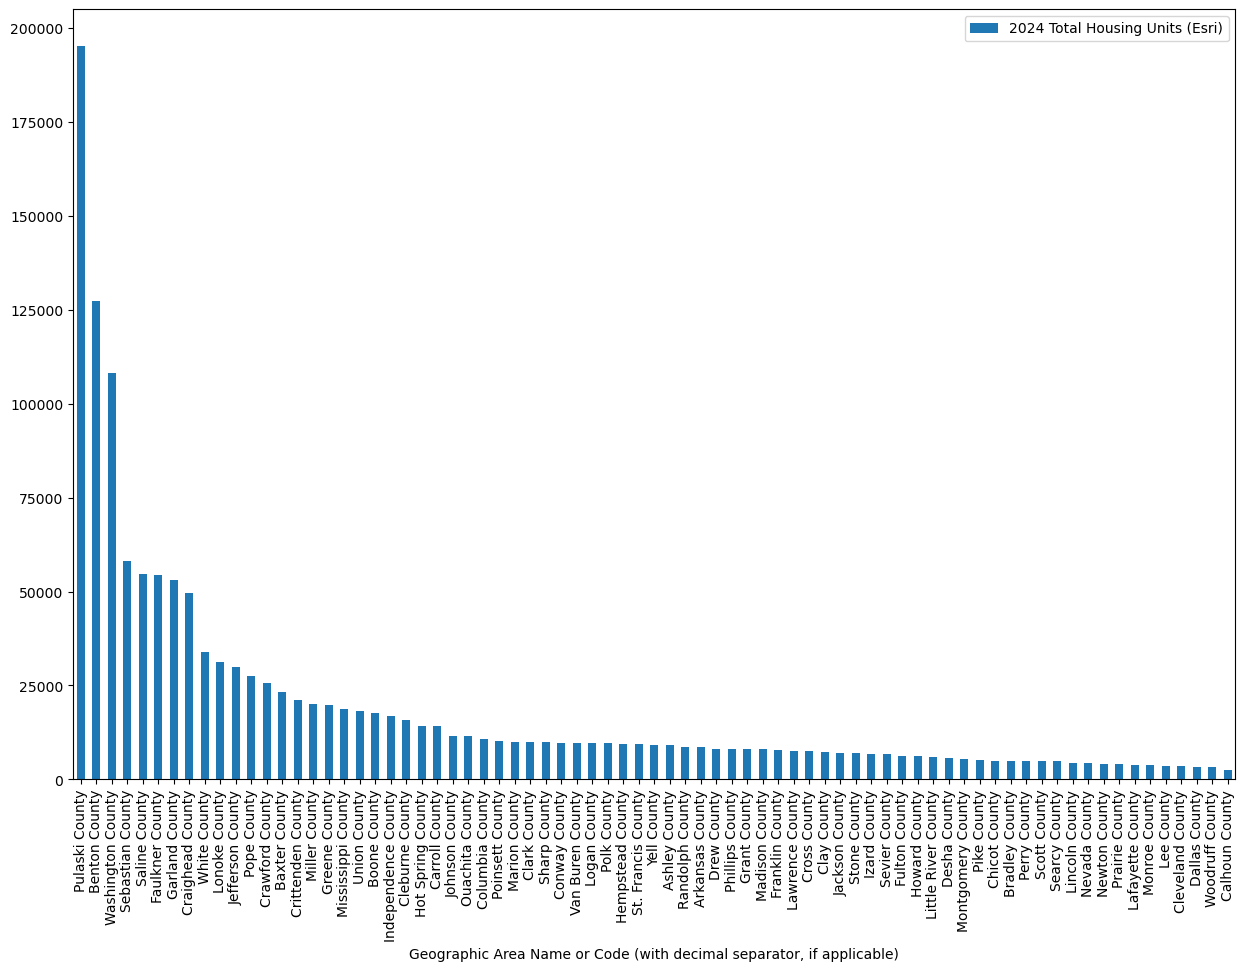

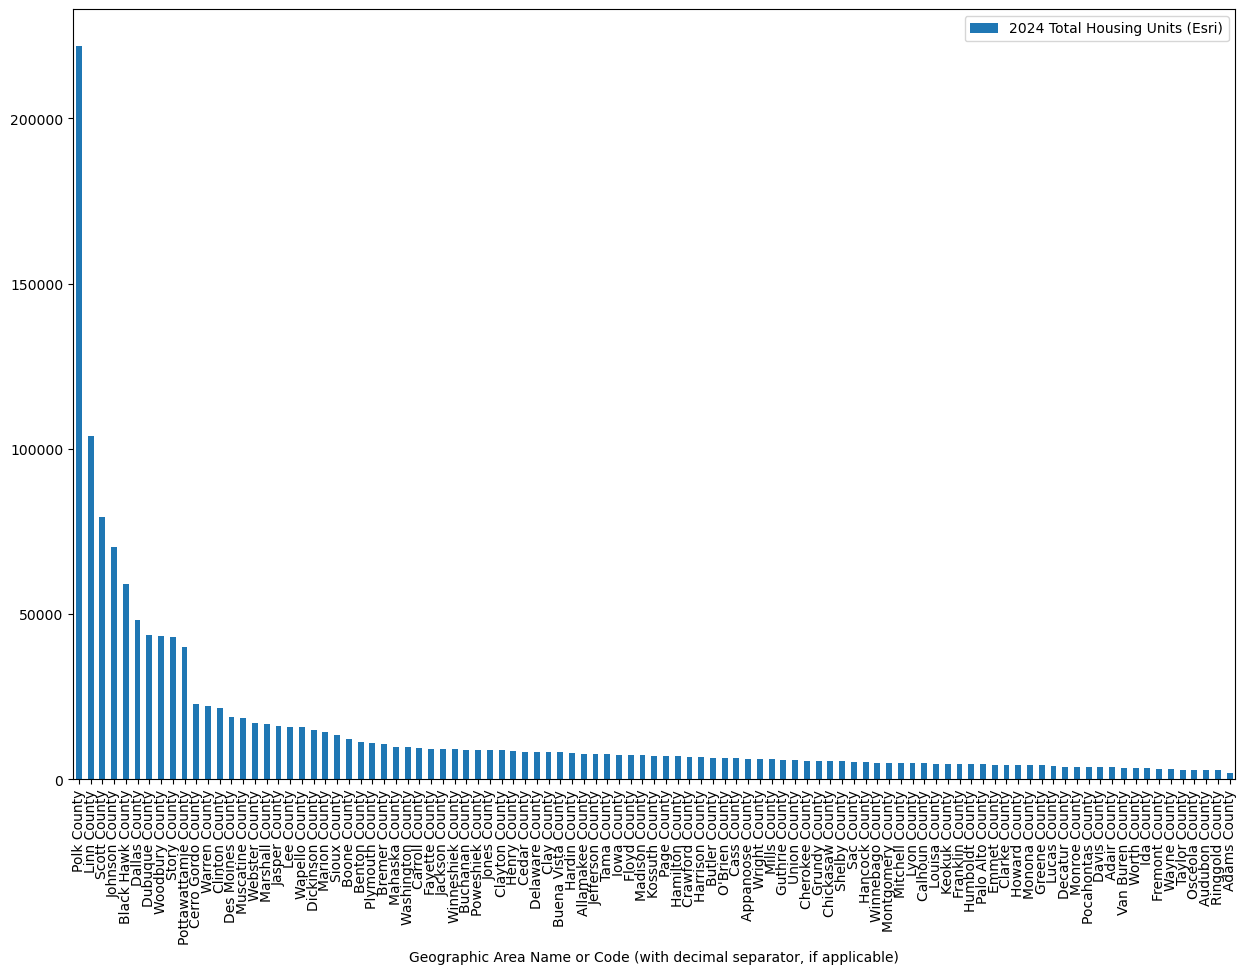

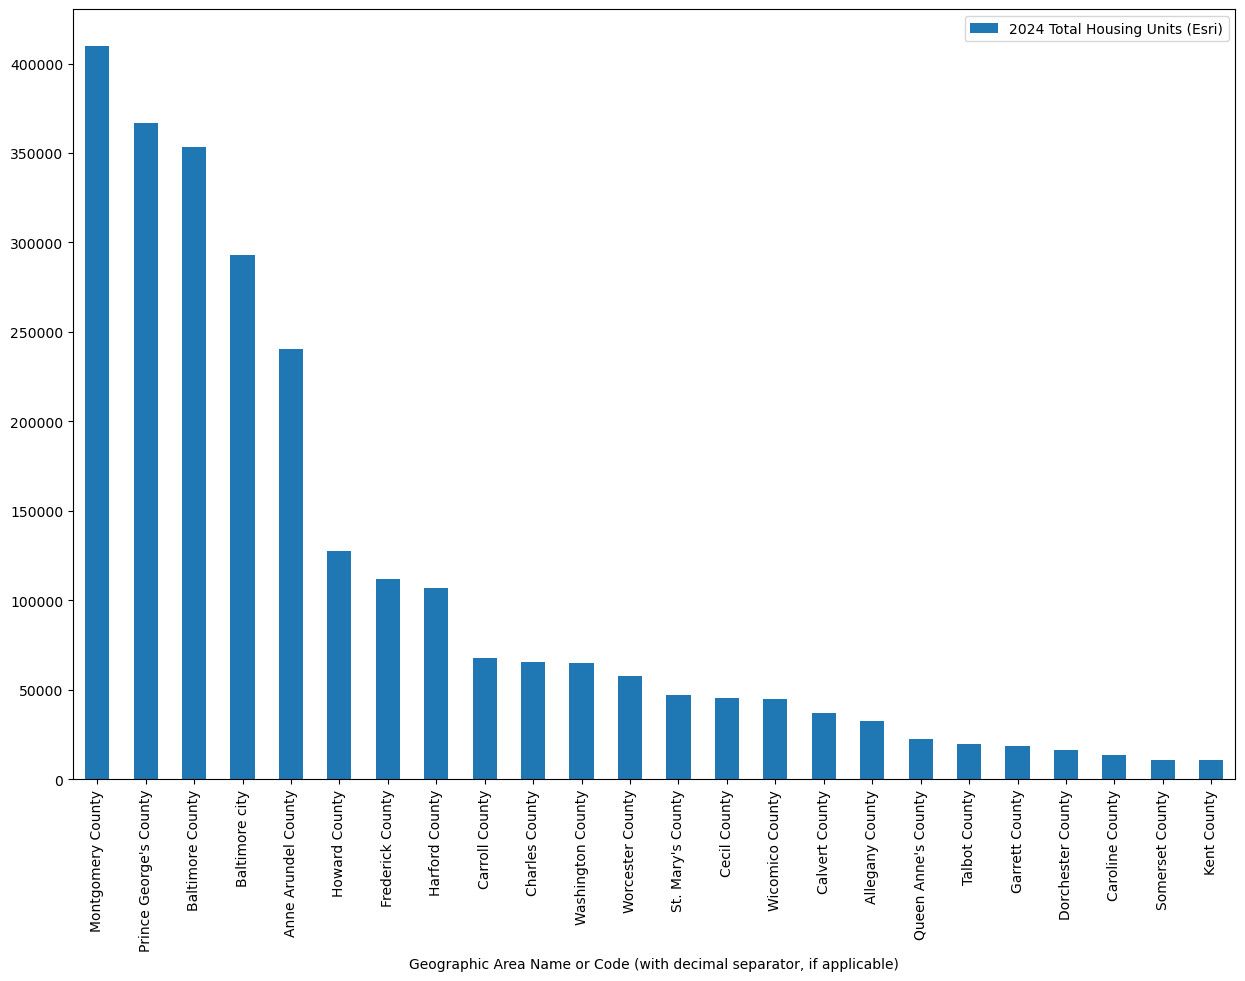

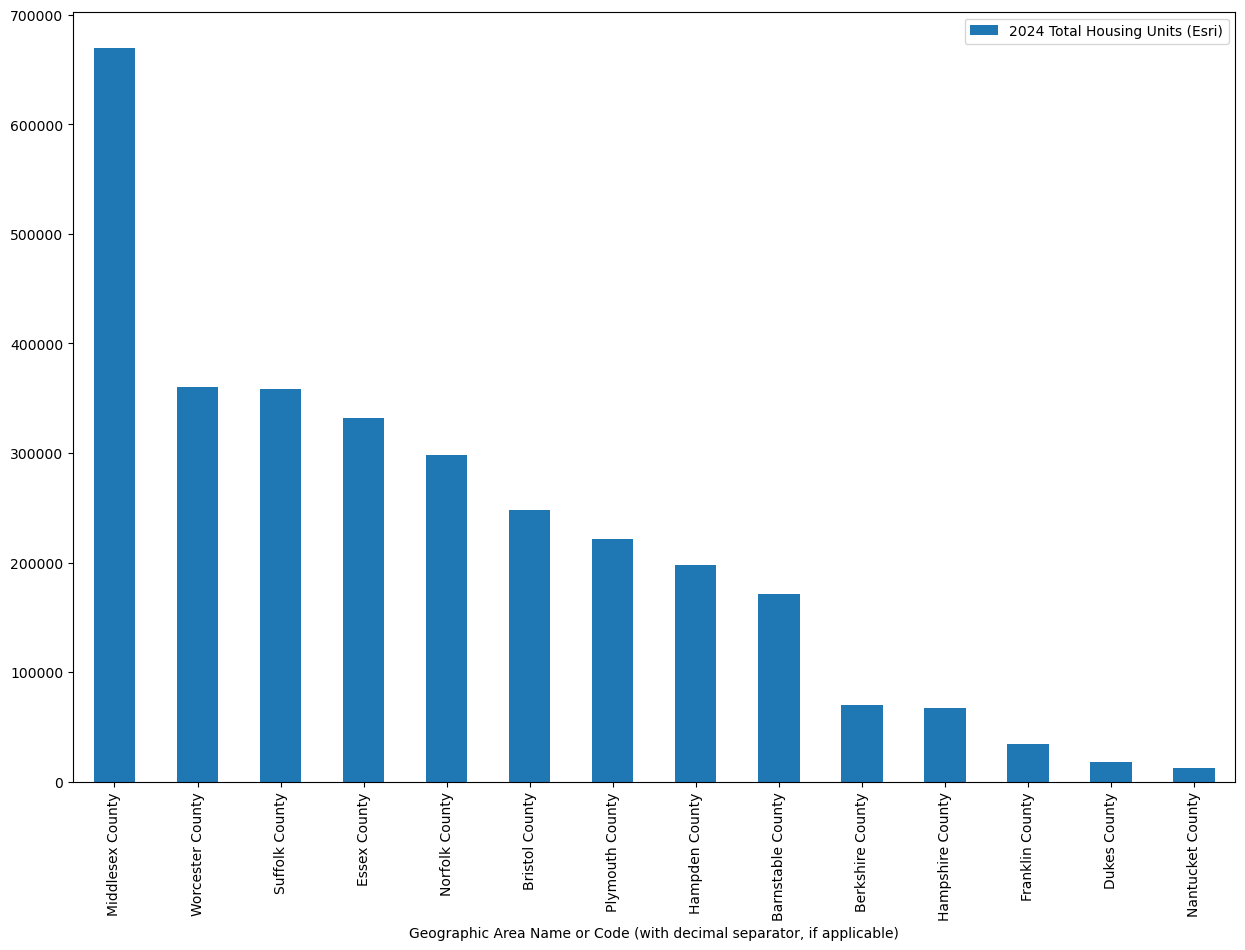

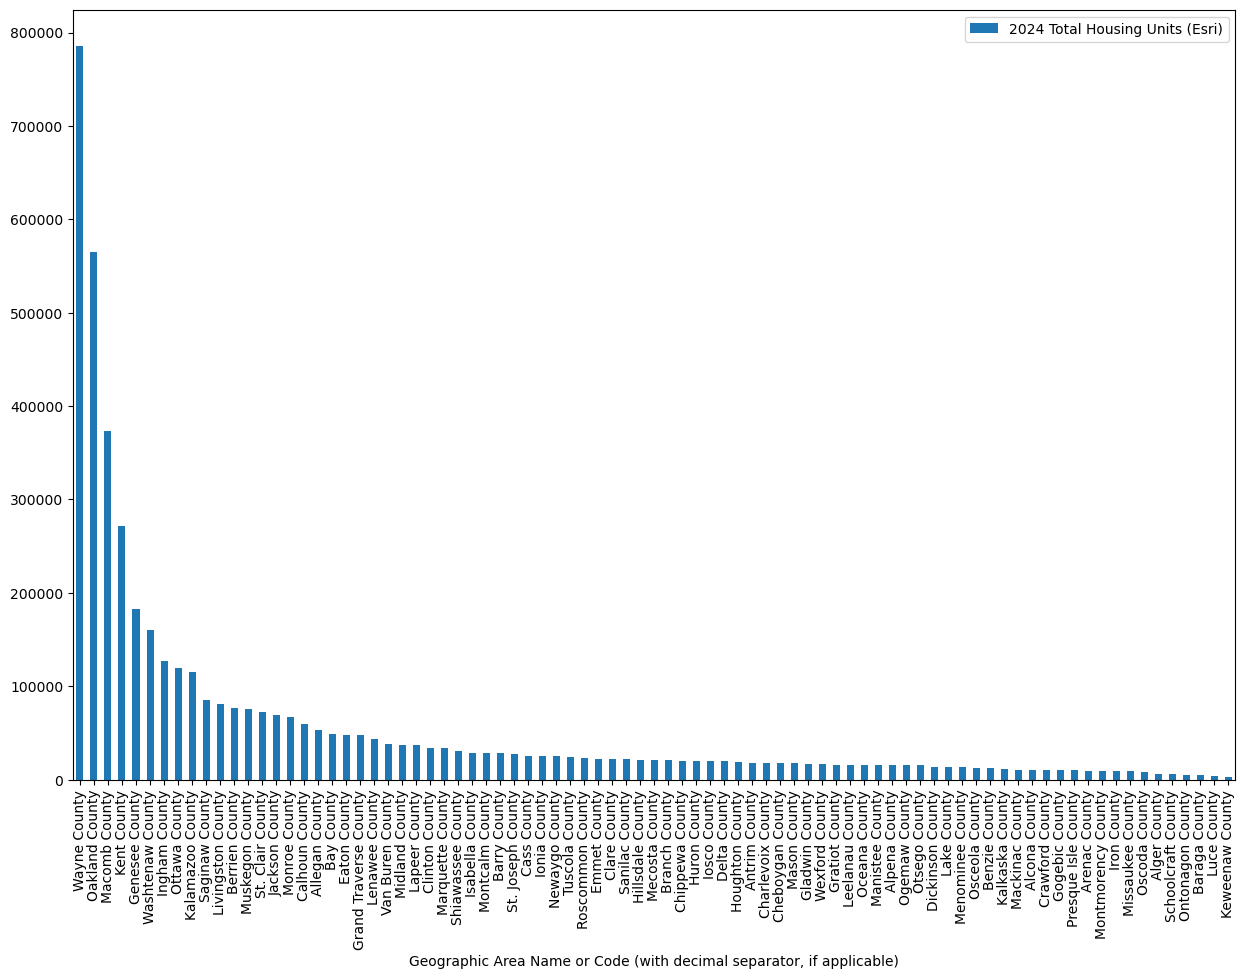

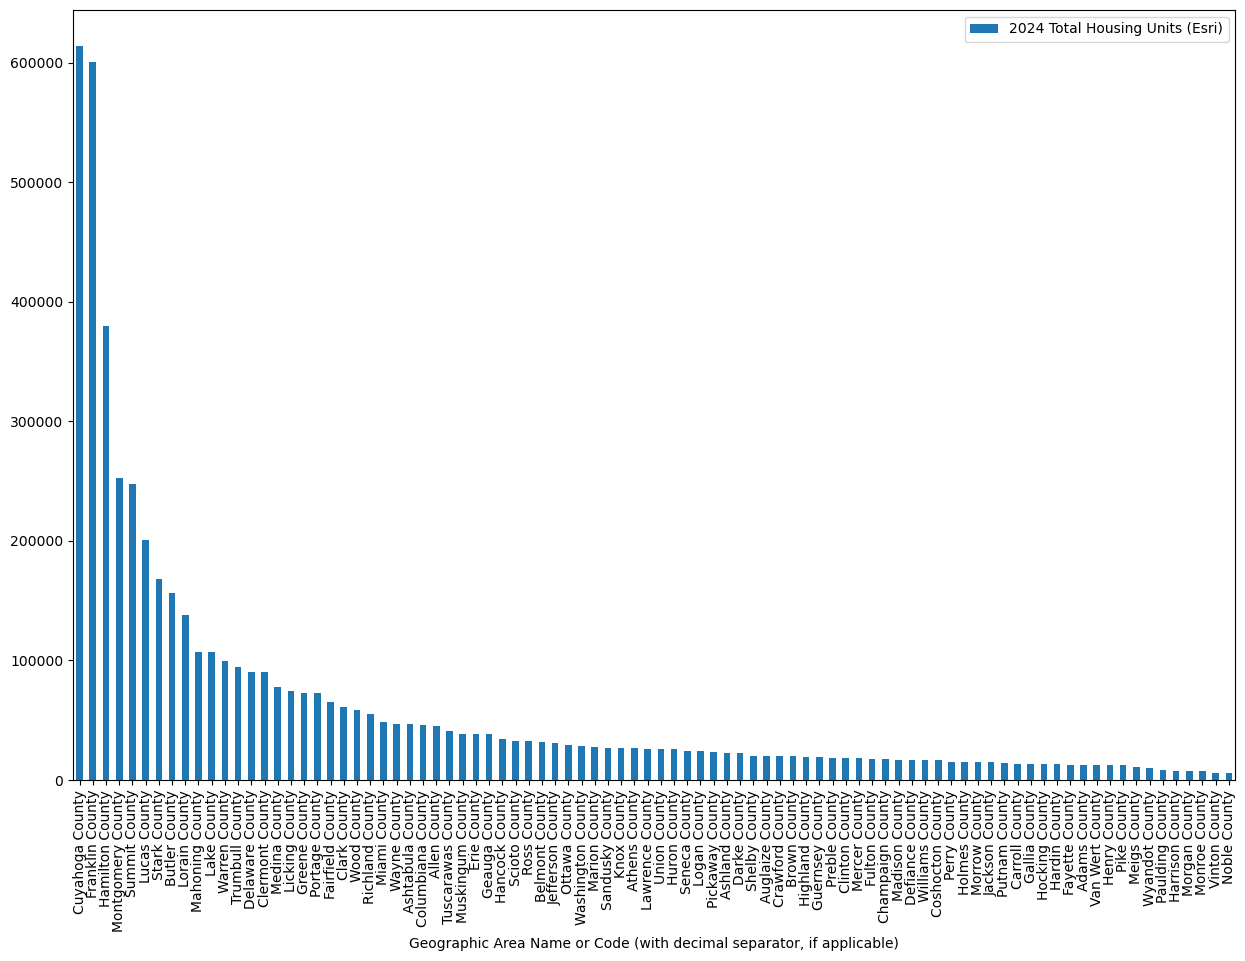

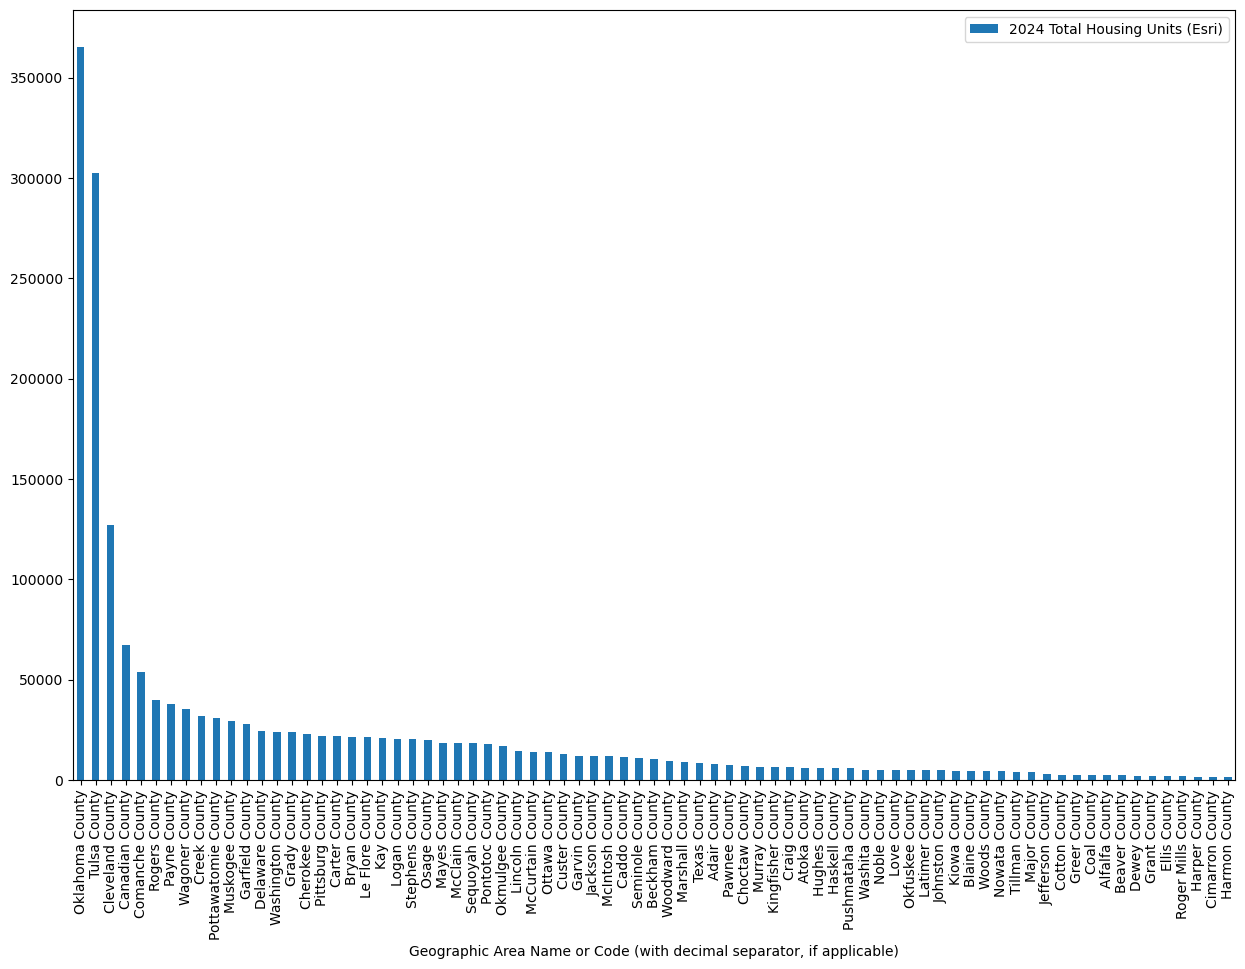

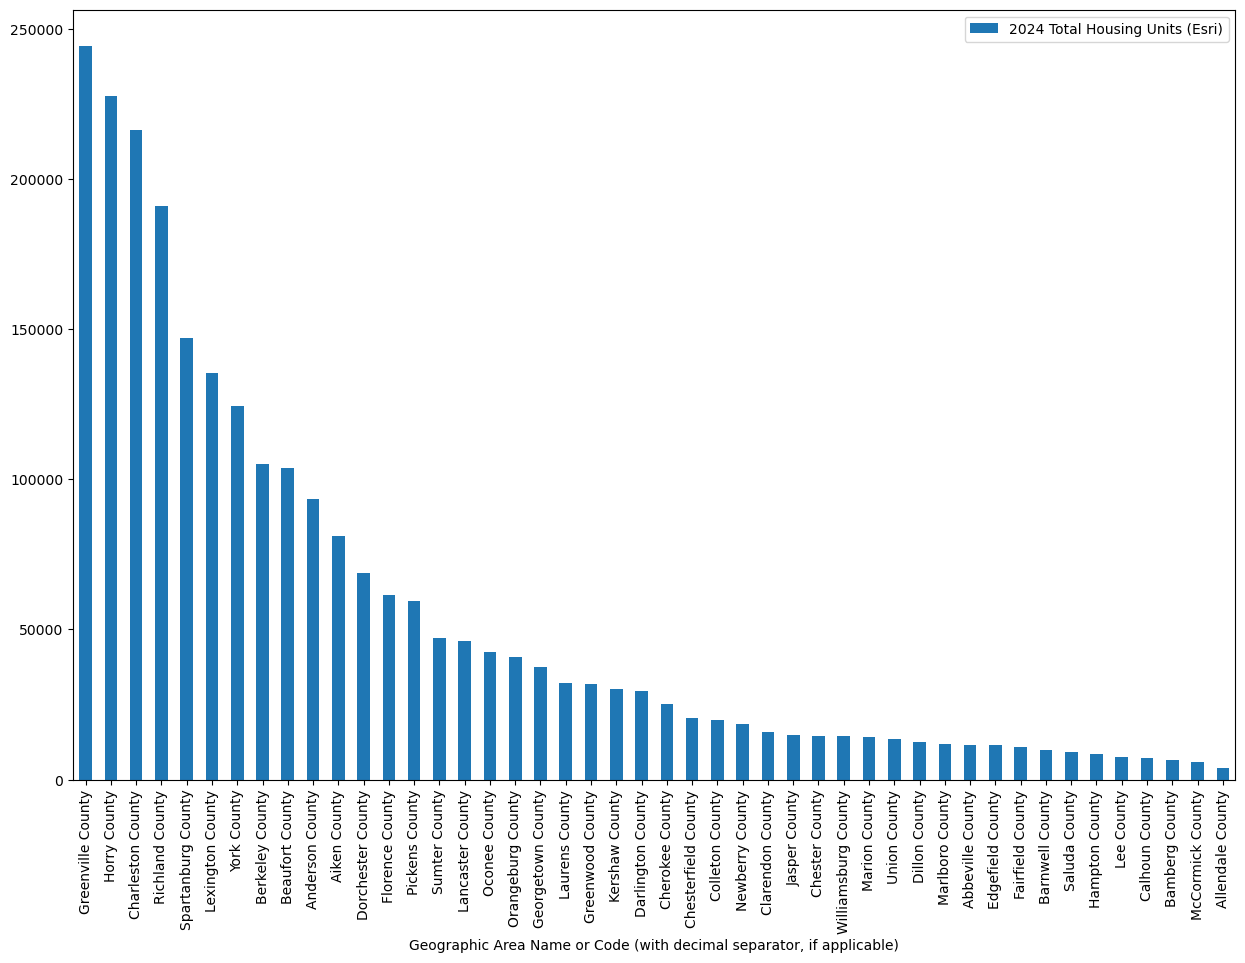

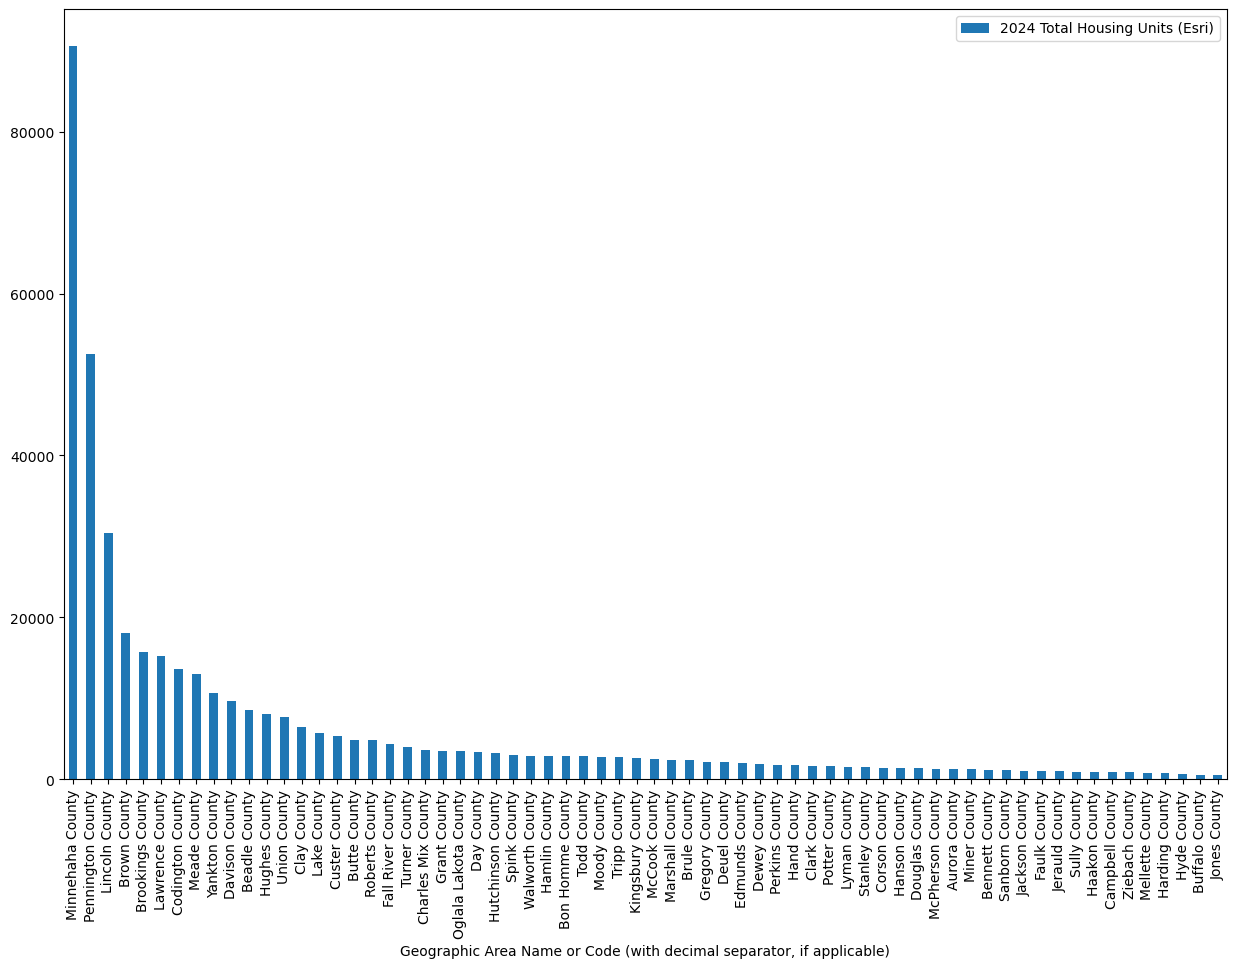

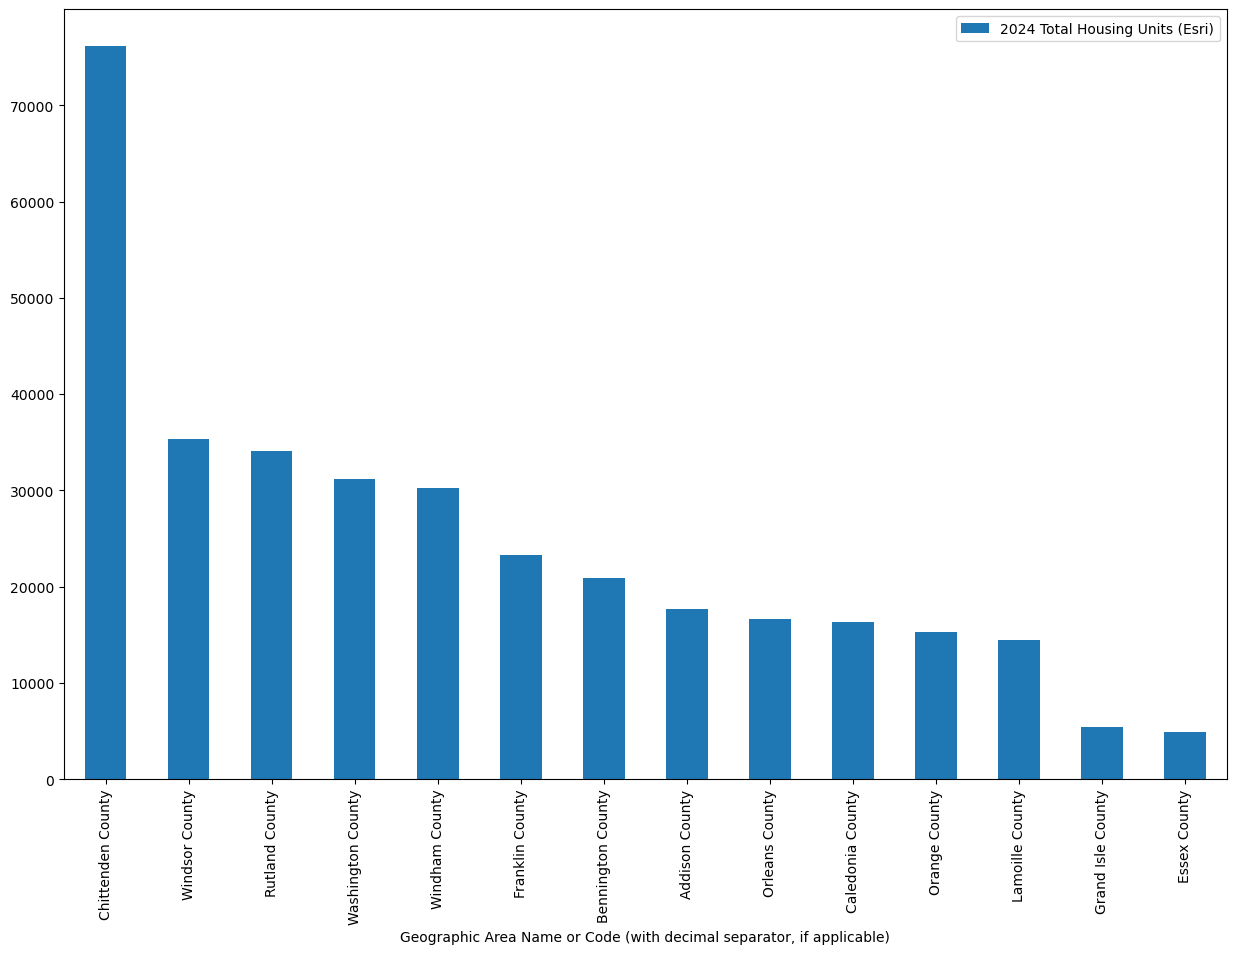

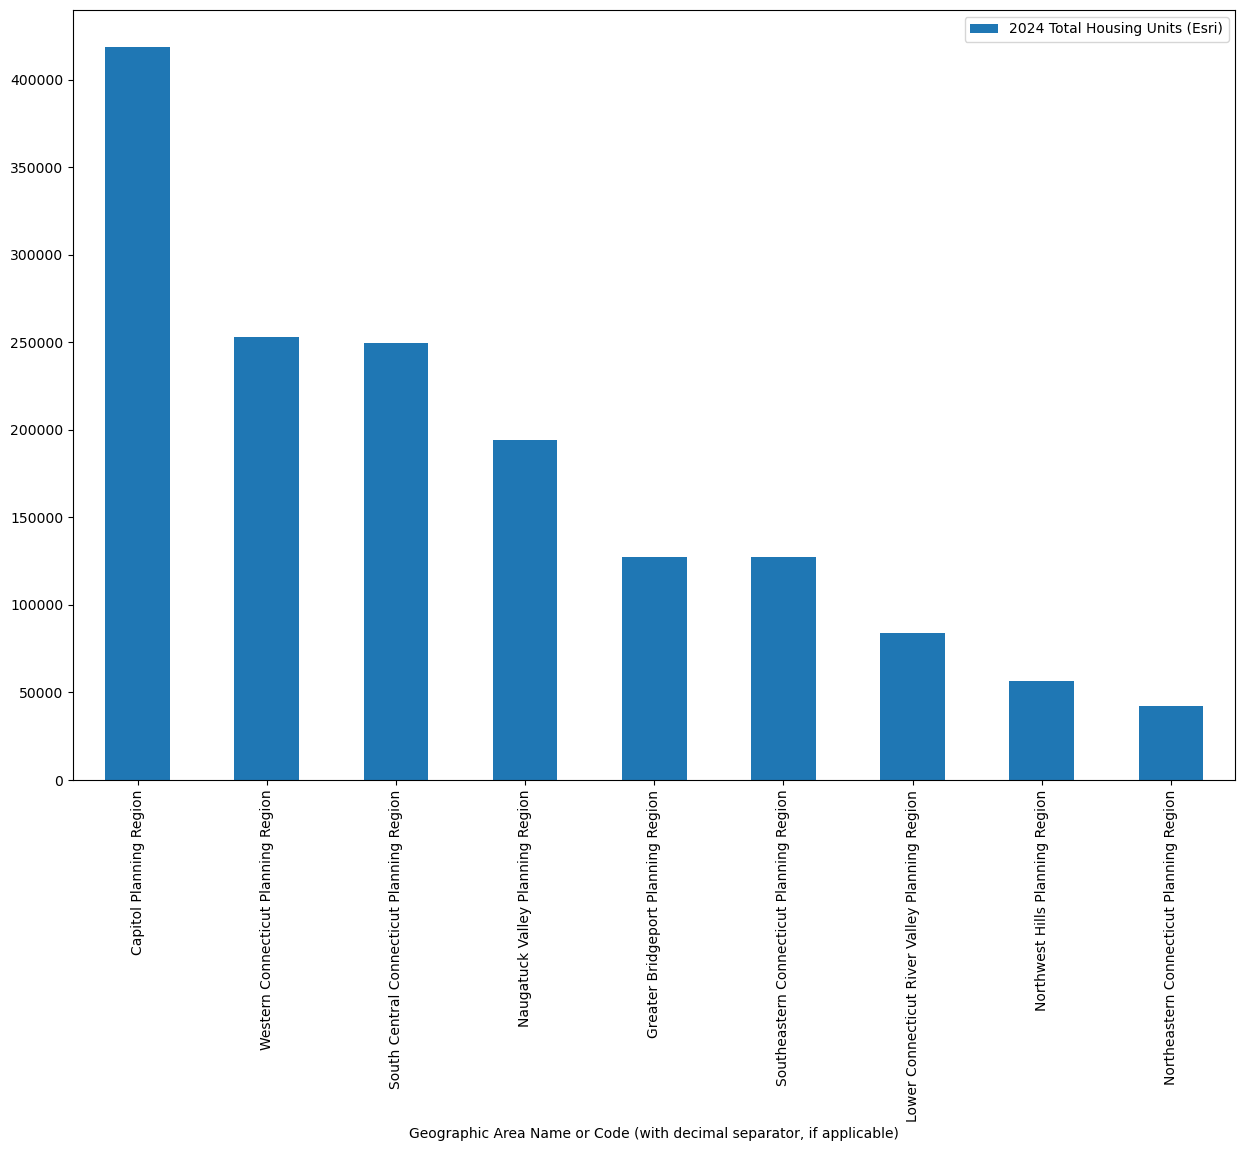

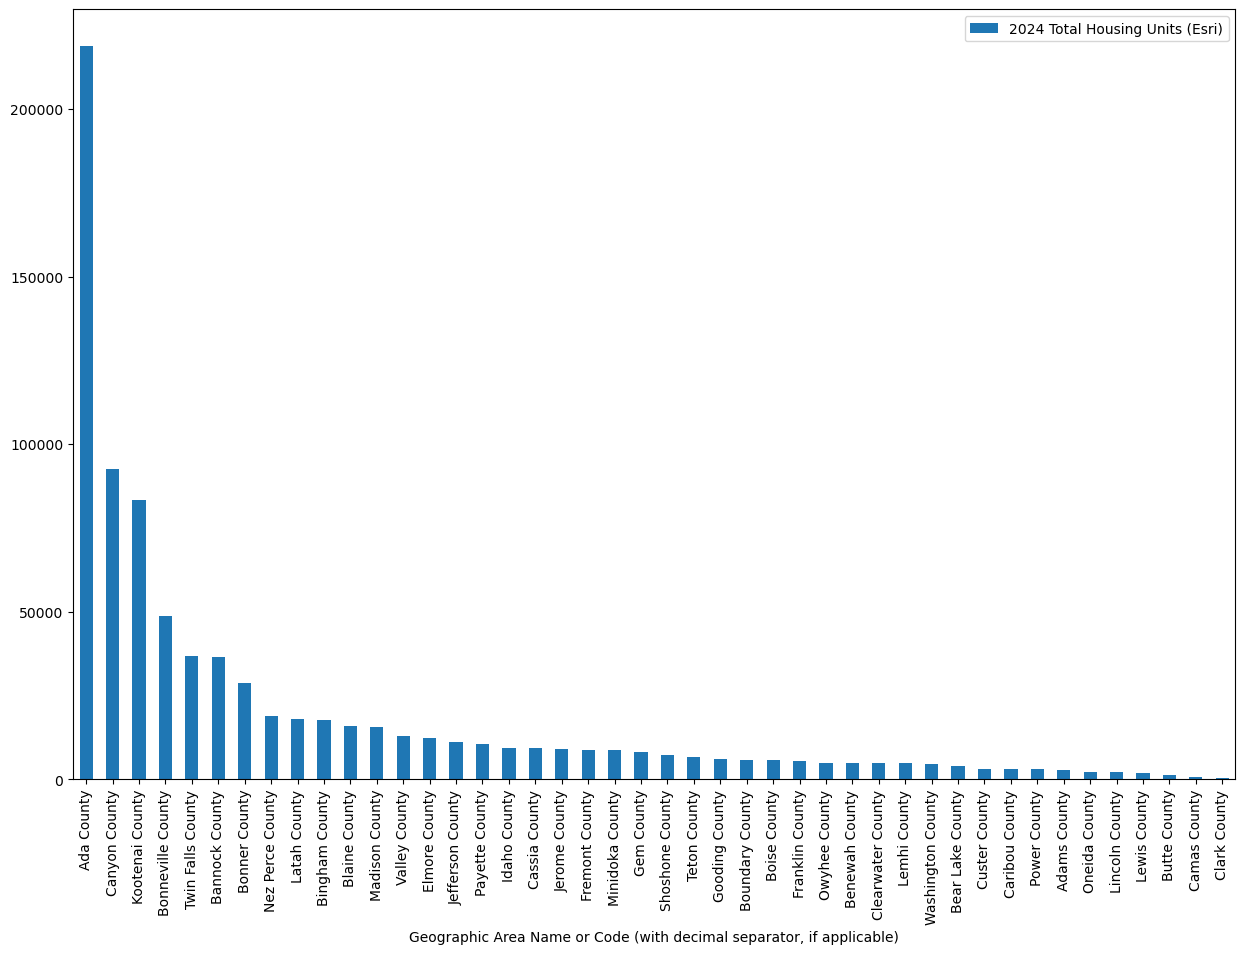

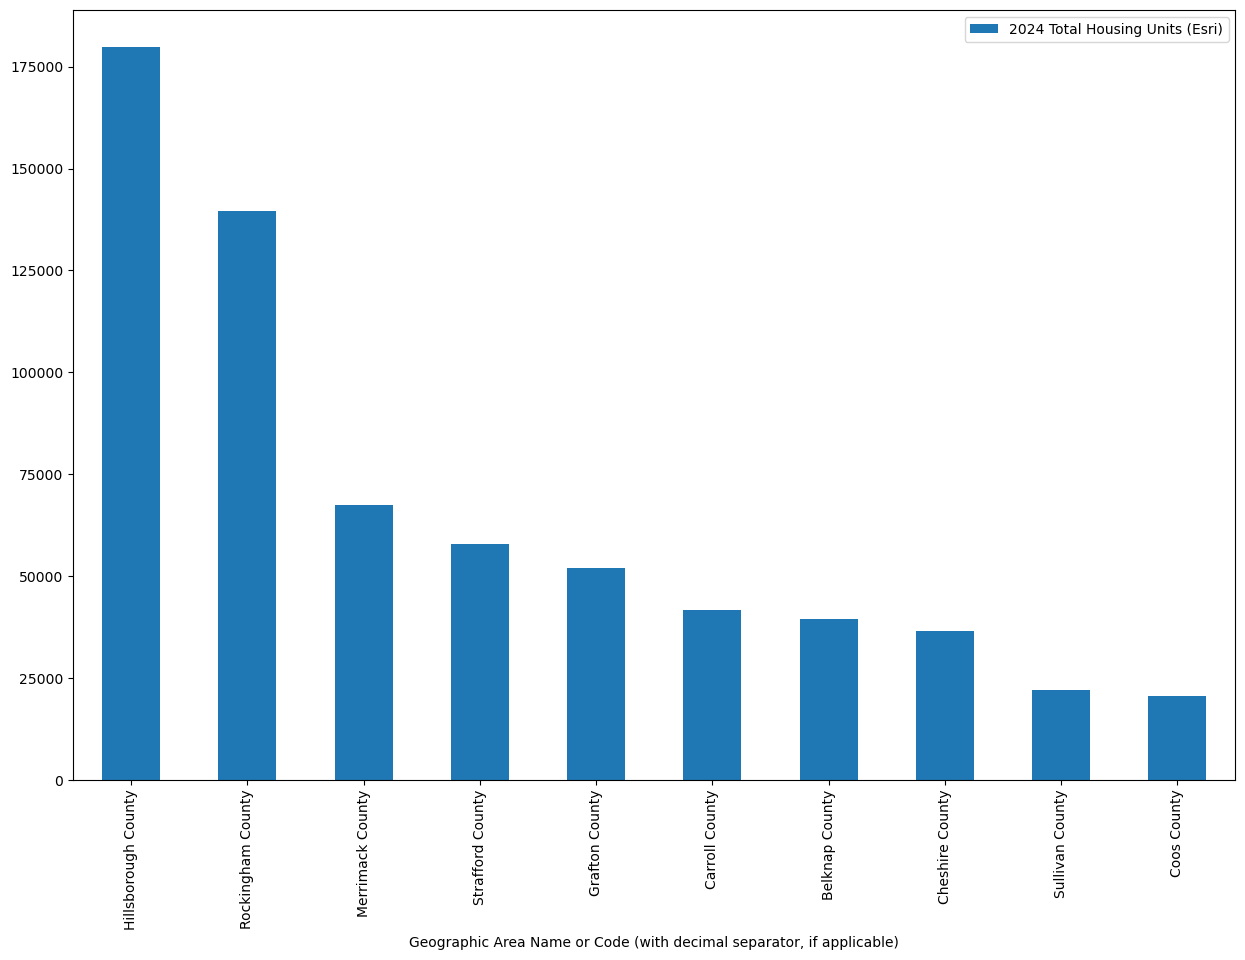

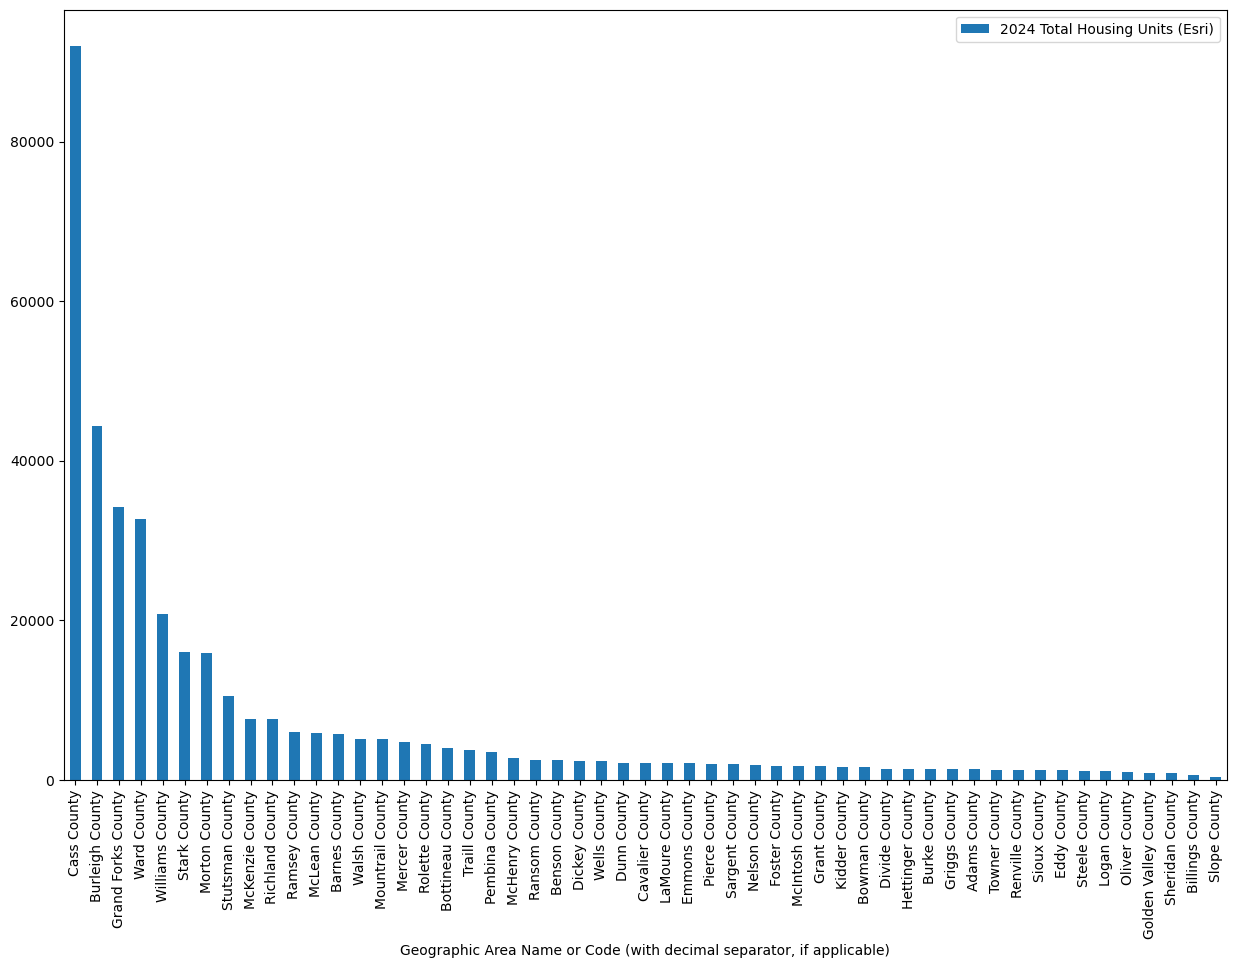

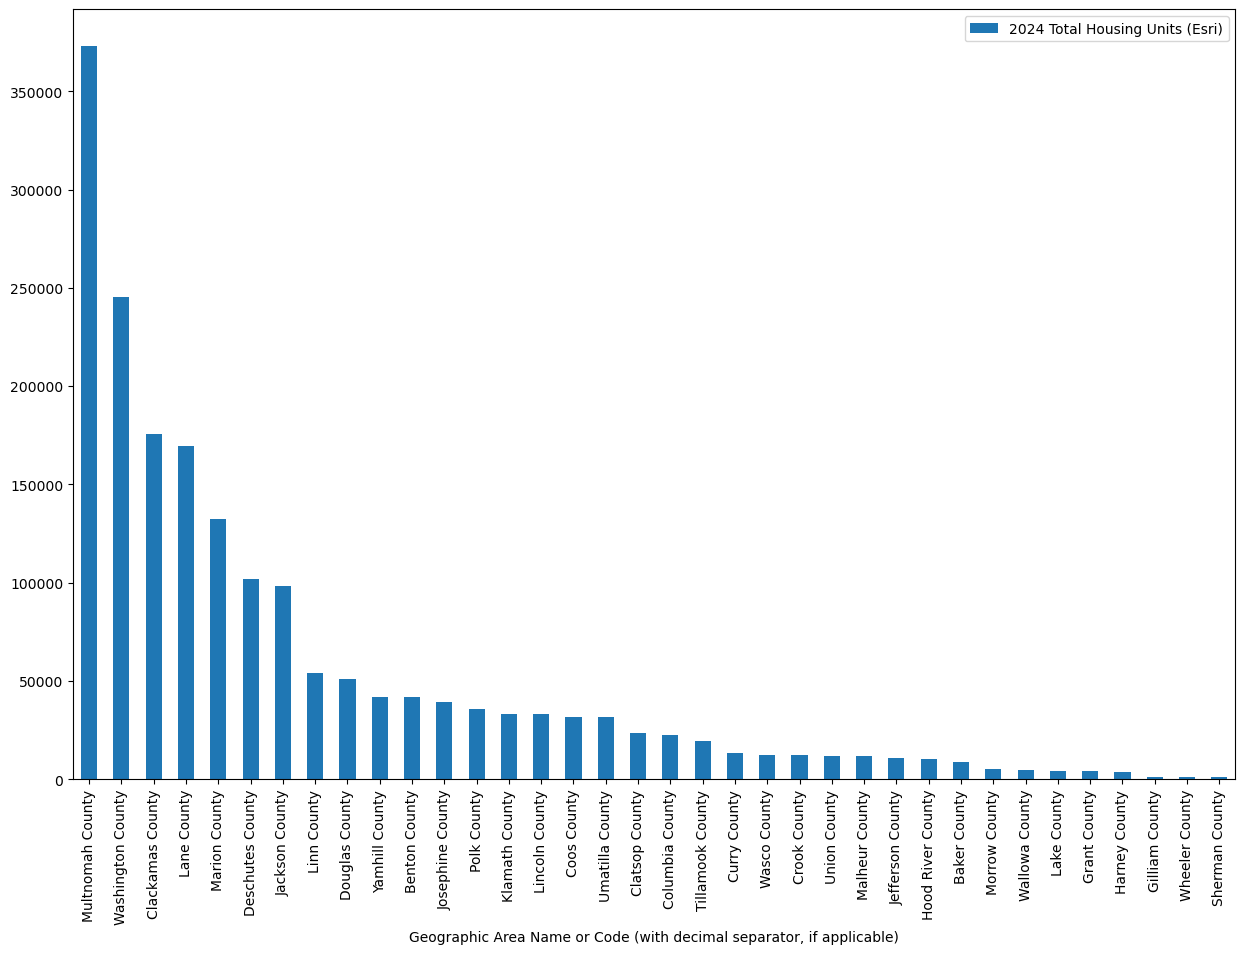

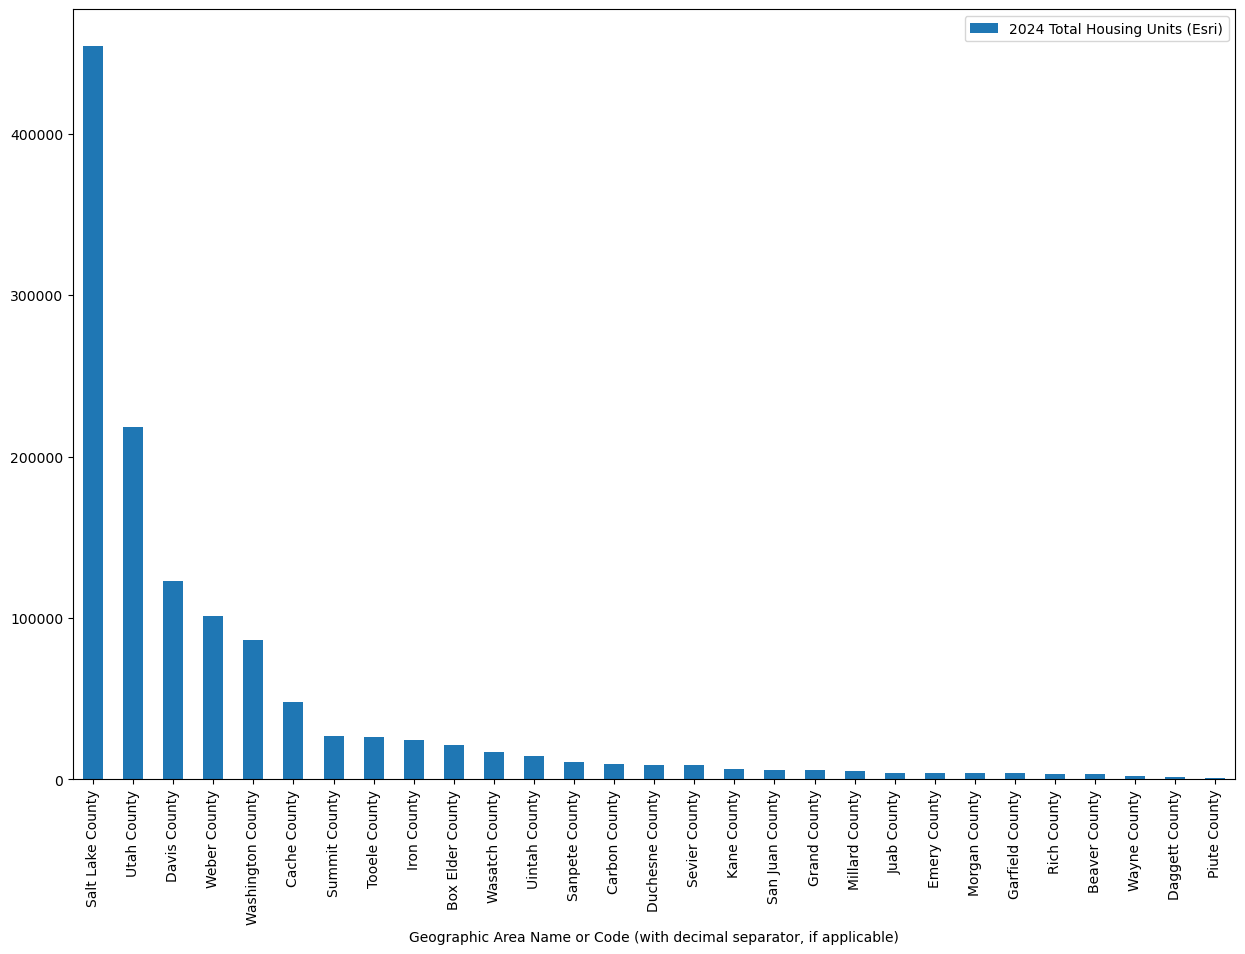

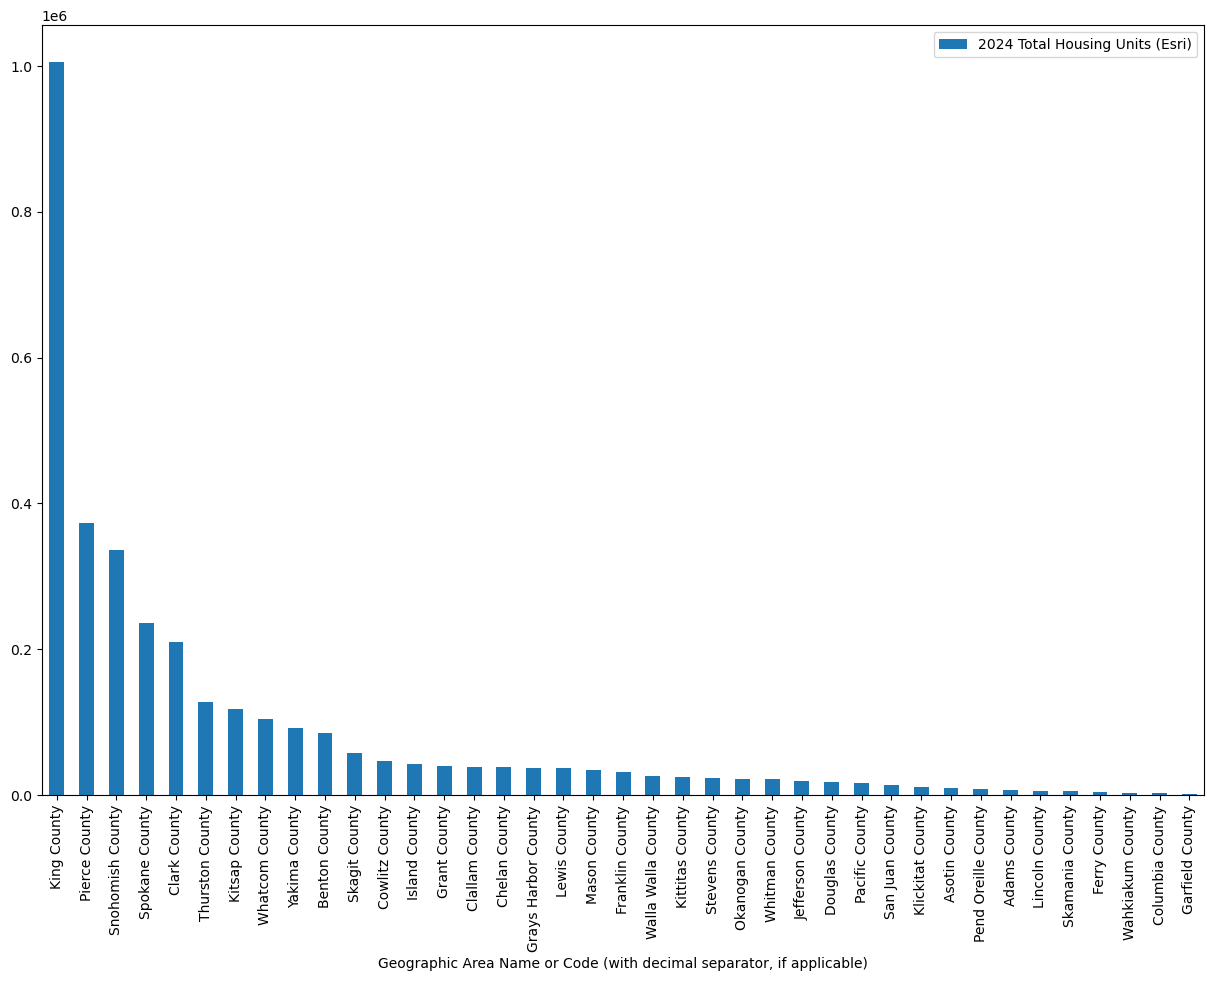

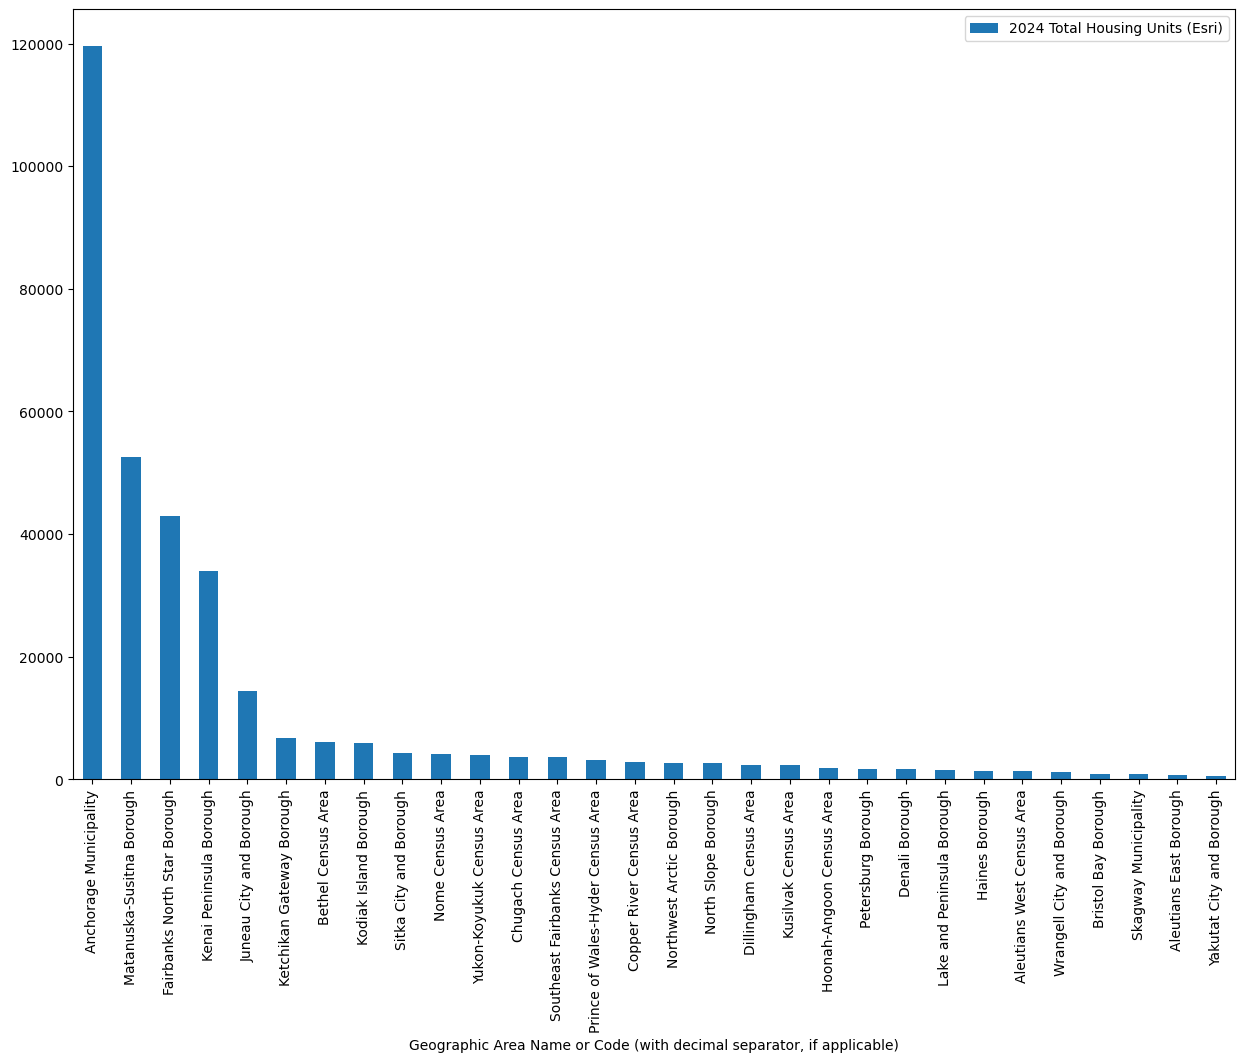

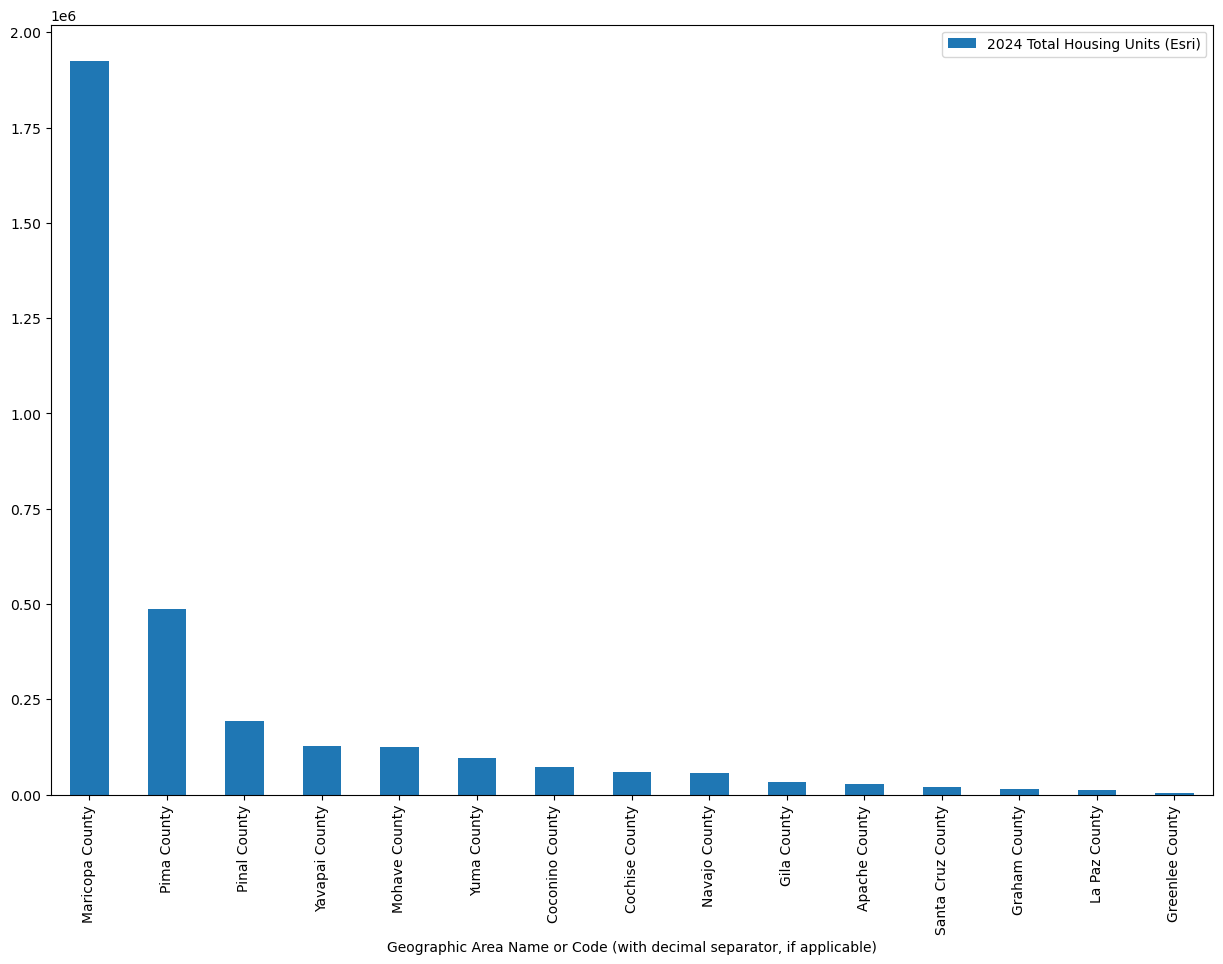

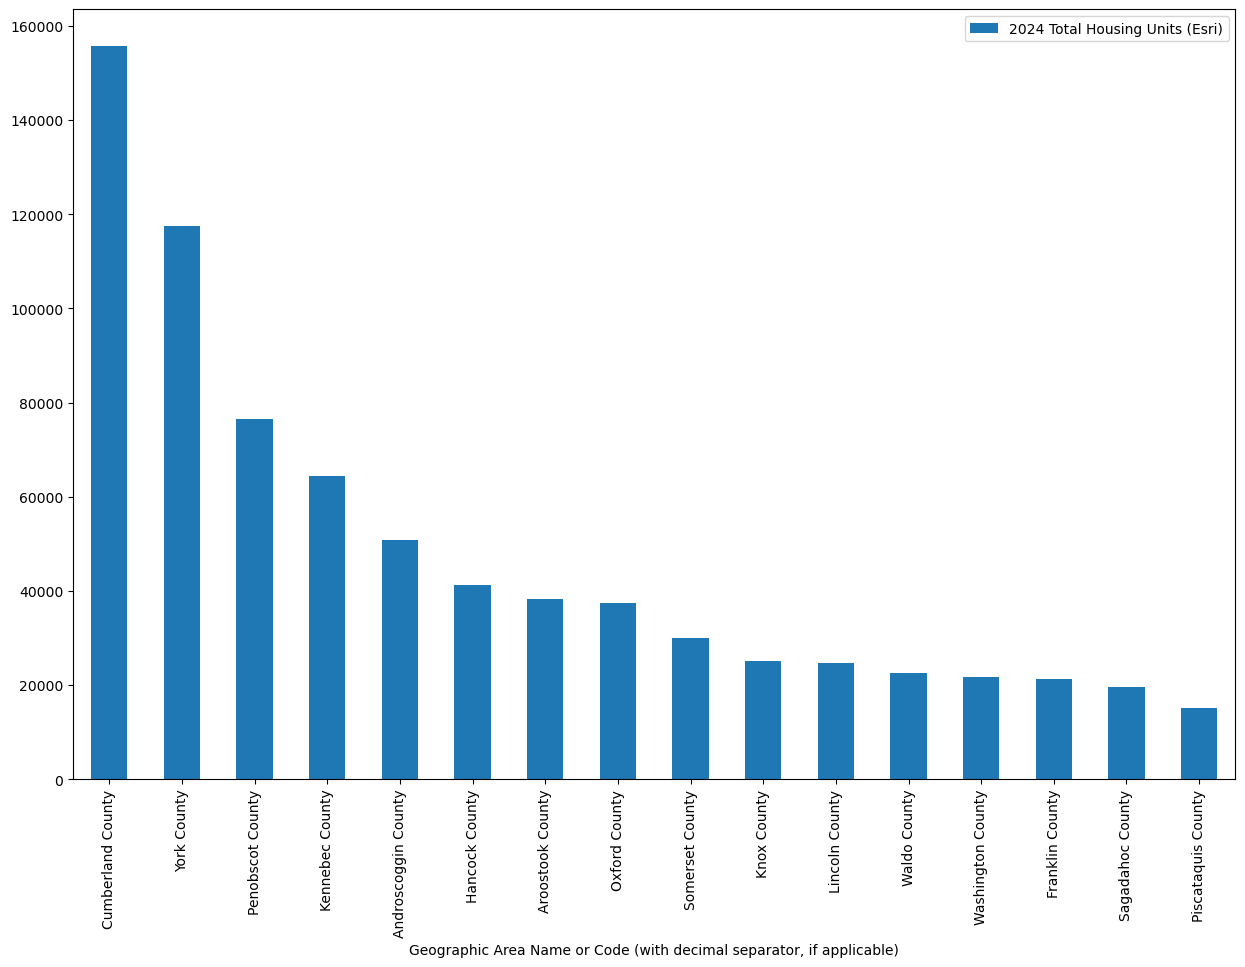

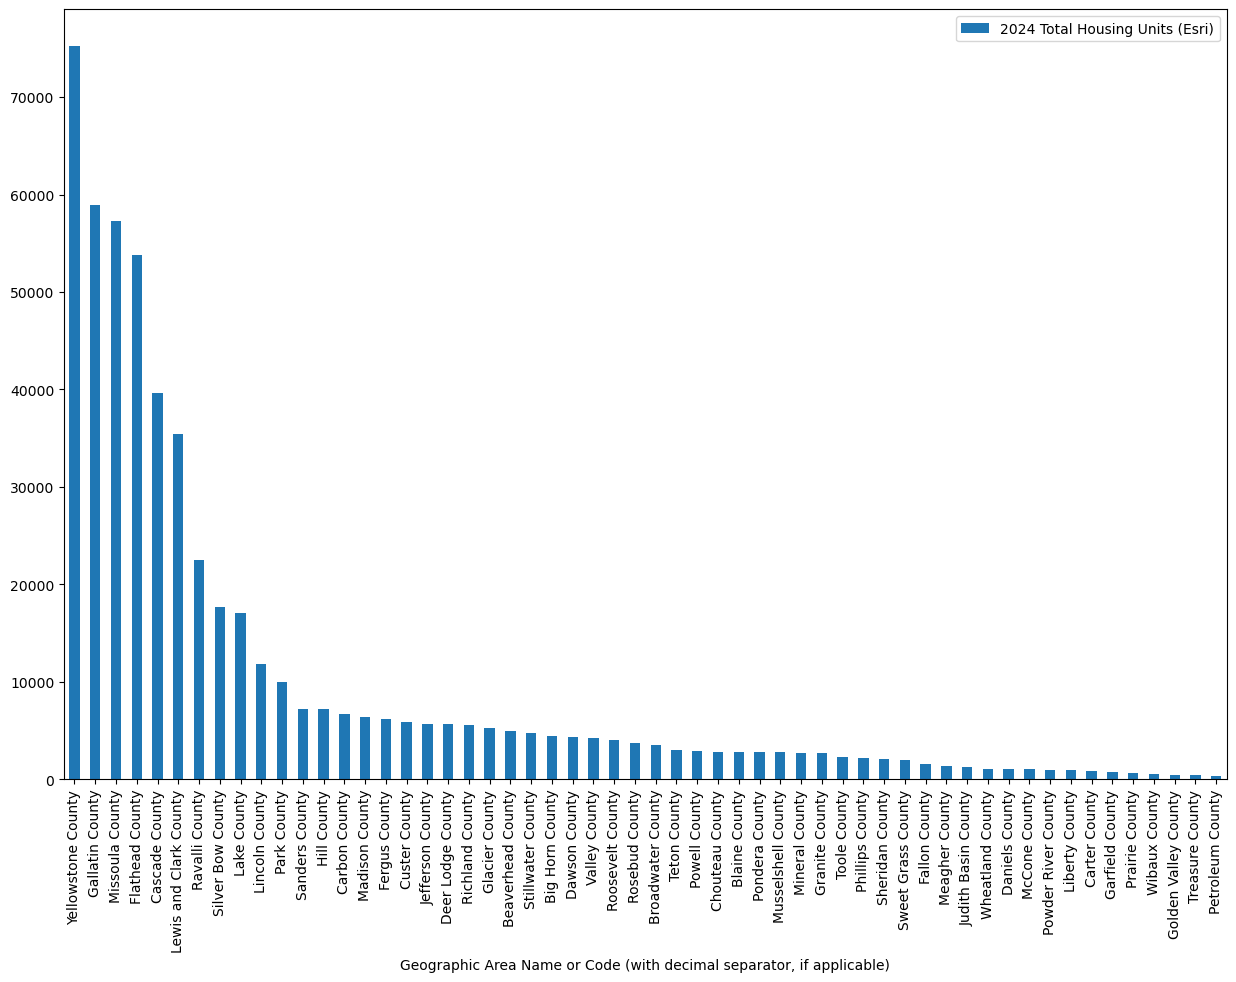

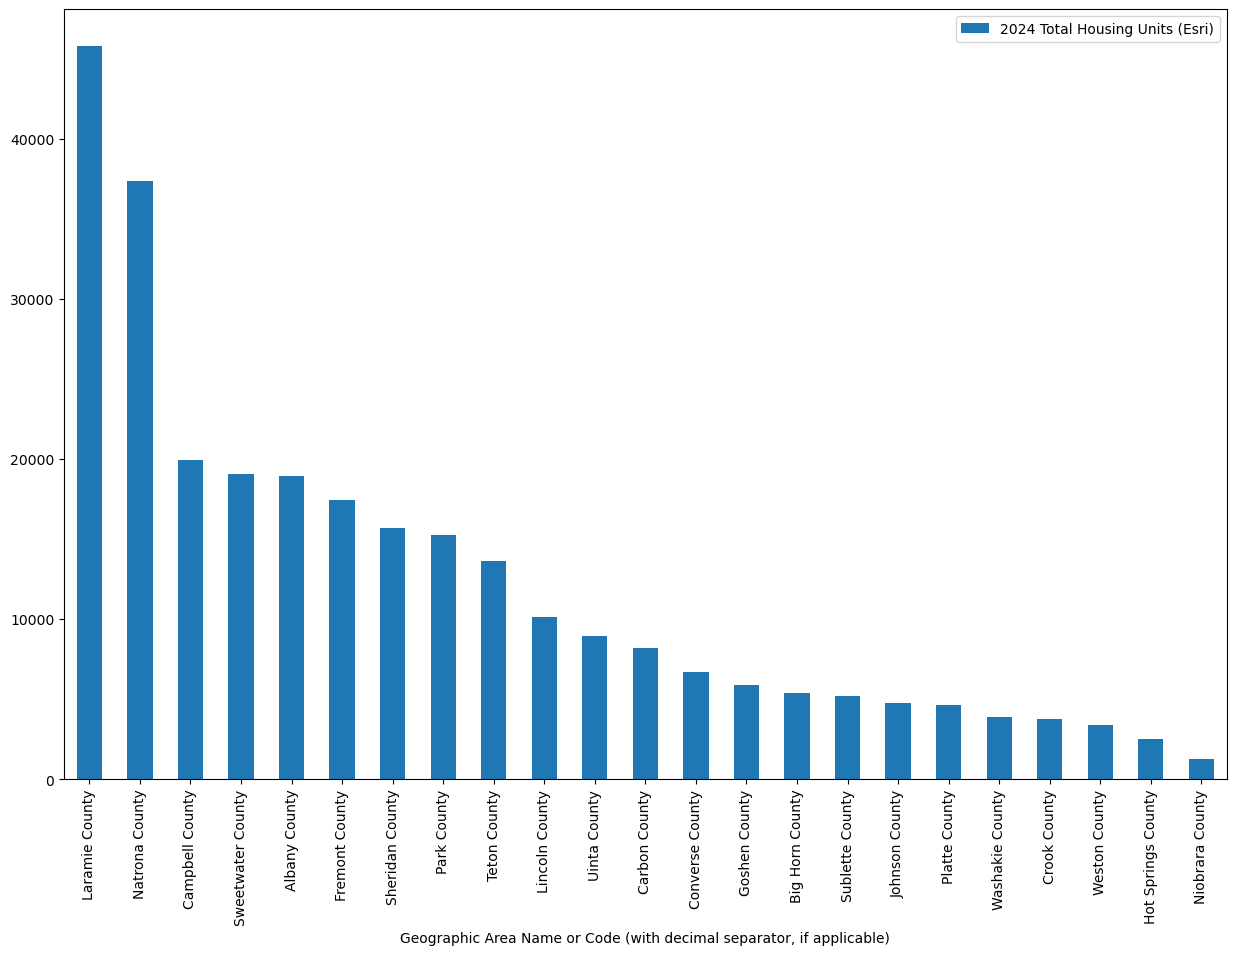

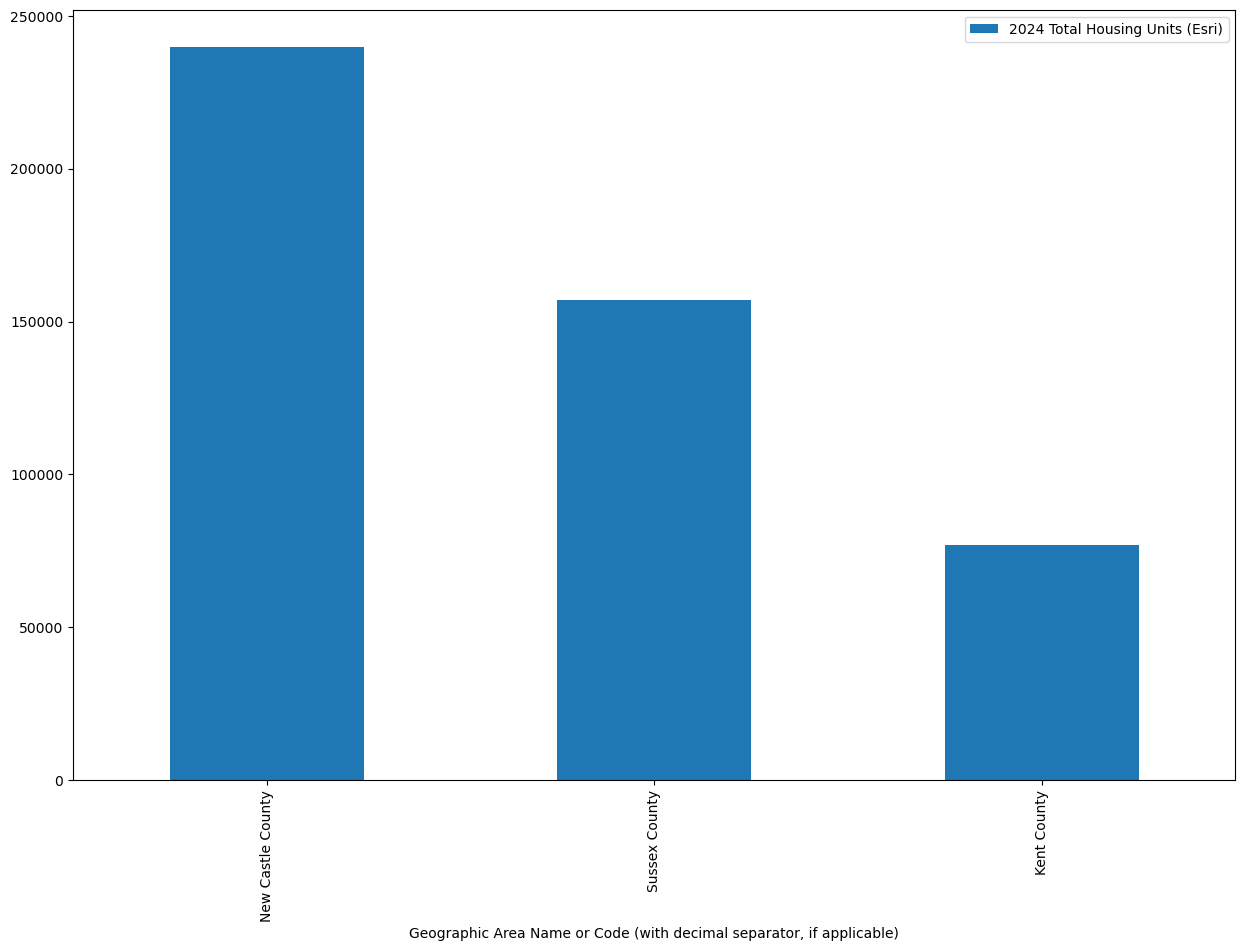

In [40]:
# loop through each state and create/save a bar chart PDF for that state's counties
# states_to_map can be large; consider filtering to a subset during development
    
    # query the state layer  # get all county rows for the current state
    # returns FeatureSet unless as_df=True
            # safe string formatting
        # directly get a pandas DataFrame for plotting

for state in states_to_map:
    df_state=lyr_counties.query(
        where = f"STATE_NAME='{state}'",
        as_df=True)
    df_state=df_state.rename(columns=field_aliases)
    df_state=df_state.sort_values(
        '2024 Total Housing Units (Esri)',
        ascending=False)
    chart = df_state.plot(
        kind='bar',
        x='Geographic Area Name or Code (with decimal separator, if applicable)',
        y='2024 Total Housing Units (Esri)',
        figsize=(15,10))
    fig = chart.get_figure()
    fig.savefig(f"./{state}.pdf")
   

    # A FeatureLayer object with query(), properties, and renderer info

    # rename the columns 
    # map raw field names to friendly aliases


# rename the DataFrame columns to use the field aliases for easier reading in charts and outputs
    # this creates nicer column headers like '2024 Total Housing Units (Esri)'

    
    # sort the values in the DataFrame so largest states appear first

    
    # create a chart object using pandas which wraps matplotlib
    
        # bar chart for county comparison
        # county names
        # numeric column to plot
        # larger figure for many states



    # convert to a matplotlib Figure so we can save it to disk
        # extract the Figure object 


    
    # save as a pdf file named after the state  # useful for distributing reports
        # overwrites existing files with same name; use safe filenames if state contains special chars

In [ ]:
# make the column names shorter and friendlier for downstream plotting and labeling
    # returns a new DataFrame reference with renamed columns

    # a concise alias for the geographic label
    # shorter numeric column name

## Working with Seaborn

In [ ]:
# seaborn provides nicer default styling for statistical plots
    # pip install seaborn if missing

In [ ]:
# set a theme and default figure size for seaborn plots
    # rc maps to matplotlib rcParams

In [ ]:
# create a seaborn barplot with one bar per county and a color per county
    # returns a matplotlib Axes object
    # DataFrame containing 'Name' and 'Total Housing Units'
    # categorical x axis — county names
    # numeric y axis
    # color each bar by name to make each county distinct (optional)
    # generate a color for each county
    # hide legend because it would duplicate x labels

# label x-axis
# label y-axis
# set chart title
# rotate x labels to reduce overlap
# get the Figure to call tight_layout or save later
# adjust padding to prevent label cutoff

## Working with Plotly

In [ ]:
# plotly for interactive charts that can be zoomed and hovered
    # pip install plotly if needed

In [ ]:
# build an interactive bar chart with Plotly Express — useful for notebooks and dashboards
    # returns a plotly.graph_objs._figure.Figure object
        # input DataFrame
        # x axis categories
        # y axis values

In [ ]:
# display the interactive Plotly figure in the notebook